# Tesla Deliveries - End-to-End ML Pipeline

**Dataset:** Tesla global delivery records, 2015–2025  
**Target:** `Estimated_Deliveries`  
**Regions:** North America, Europe, Asia, Middle East  
**Models:** Model S, Model X, Model 3, Model Y, Cybertruck

---

## Notebook Structure

| Section | Description | Type |
|---|---|---|
| 1. Preprocessing | Cleaning, encoding, feature creation | Requirement |
| 2. EDA | Trends, distributions, correlations | Requirement |
| 3. Feature Engineering | Lags, cyclical, ratios | Requirement |
| 4. Regression | Linear Regression (syllabus model) | Requirement |
| 5. Tree Models Comparison | Random Forest, XGBoost | Requirement |
| 6. Hyperparameter Tuning | Ridge / Lasso / ElasticNet (GridSearchCV) | Requirement |
| 7. Time Series Forecasting | Linear Regression + Lag Features (recursive) | Requirement |
| 8. Explainability | Coefficients, Permutation Importance, SHAP | Enhancement |
| 9. Error Analysis | Where does the model fail? | Enhancement |
| 10. Trend Analysis | 2015–2020 vs 2021–2025 | Enhancement |
| 11. Clustering | Vehicle segment discovery | Enhancement |

## 0. Imports & Setup

In [78]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import xgboost as xgb
import shap

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SEED = 42
np.random.seed(SEED)
print('All imports successful')

All imports successful


## Section 1 — Preprocessing

In [79]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [80]:
# Basic info
df.info()

# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None, dataset is complete ')

# Duplicate rows 
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
df = df.drop_duplicates().reset_index(drop=True)

# Proper datetime column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))

#  Ordinal time index 
df['Time_Index'] = df['Year'] * 12 + df['Month']

print('Date column created ')
df[['Year', 'Month', 'Date', 'Time_Index']].head()

# Label-encode Region, Model, Source_Type so ML models can use them
# Keep originals for EDA readability
le = LabelEncoder()
for col in ['Region', 'Model', 'Source_Type']:
    df[col + '_enc'] = le.fit_transform(df[col])

print('Encoded columns added:')
print([c for c in df.columns if c.endswith('_enc')])
df[['Region', 'Region_enc', 'Model', 'Model_enc']].drop_duplicates().sort_values('Region')

# Statistical summary
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
Missing values per column:
None, dataset is complete 
Duplicate rows: 0
Date column created 
Encoded columns added:

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,Time_Index,Region_enc,Model_enc,Source_Type_enc
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13,2020-06-16 02:10:54.545454592,24246.50,1.50,2.00,1.00
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00,2015-01-01 00:00:00,24181.00,0.00,0.00,0.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75,2017-09-23 12:00:00,24213.75,0.75,1.00,0.00
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50,2020-06-16 00:00:00,24246.50,1.50,2.00,1.00
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00,2023-03-08 18:00:00,24279.25,2.25,3.00,2.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00,2025-12-01 00:00:00,24312.00,3.00,4.00,2.00
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57,NaN,38.11,1.12,1.41,0.82


## Section 2 - Exploratory Data Analysis (EDA)

### 2.1 Target Distribution

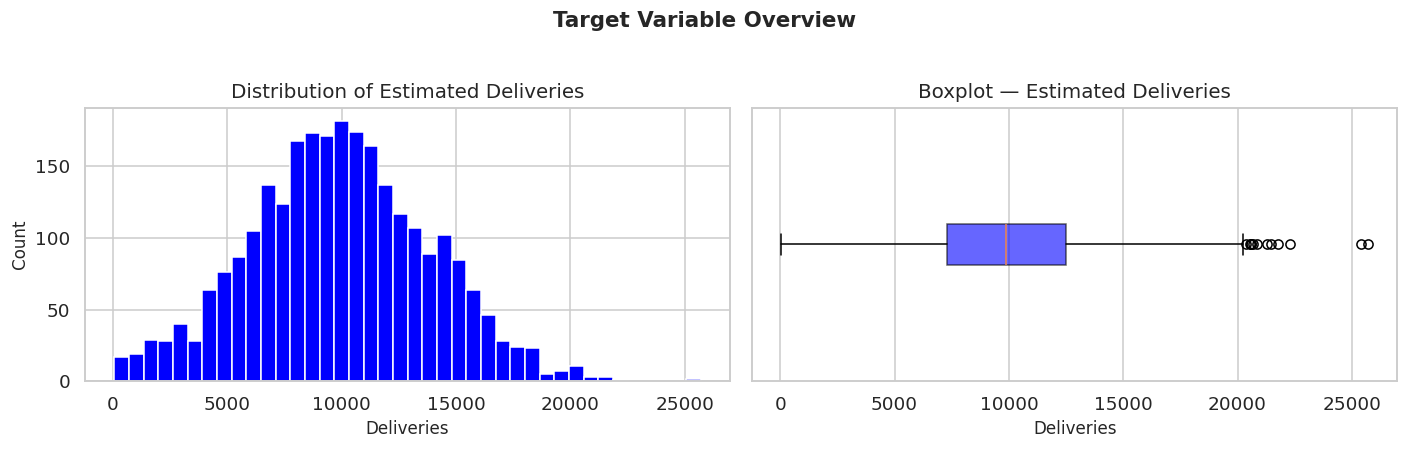

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of deliveries
axes[0].hist(df['Estimated_Deliveries'], bins=40, color='blue', edgecolor='white')
axes[0].set_title('Distribution of Estimated Deliveries')
axes[0].set_xlabel('Deliveries')
axes[0].set_ylabel('Count')

# Box plot to spot outliers
axes[1].boxplot(df['Estimated_Deliveries'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='blue', alpha=0.6))
axes[1].set_title('Boxplot — Estimated Deliveries')
axes[1].set_xlabel('Deliveries')
axes[1].set_yticks([])

plt.suptitle('Target Variable Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Sales Trend Over Years

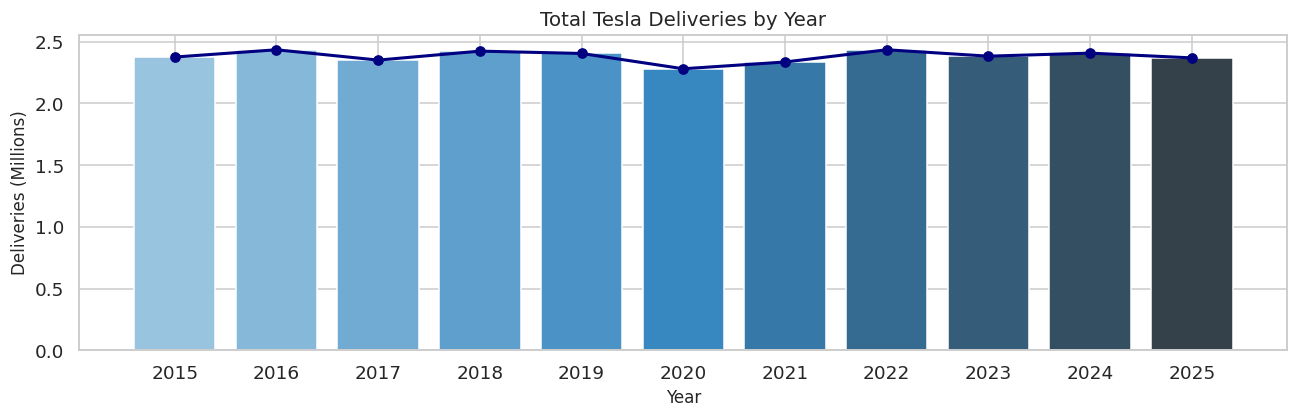

In [82]:
# Aggregate total deliveries per year
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
       color=sns.color_palette('Blues_d', len(yearly)))
ax.plot(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
        marker='o', color='navy', linewidth=2)
ax.set_title('Total Tesla Deliveries by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Deliveries (Millions)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

### 2.3 Monthly Seasonality Heatmap

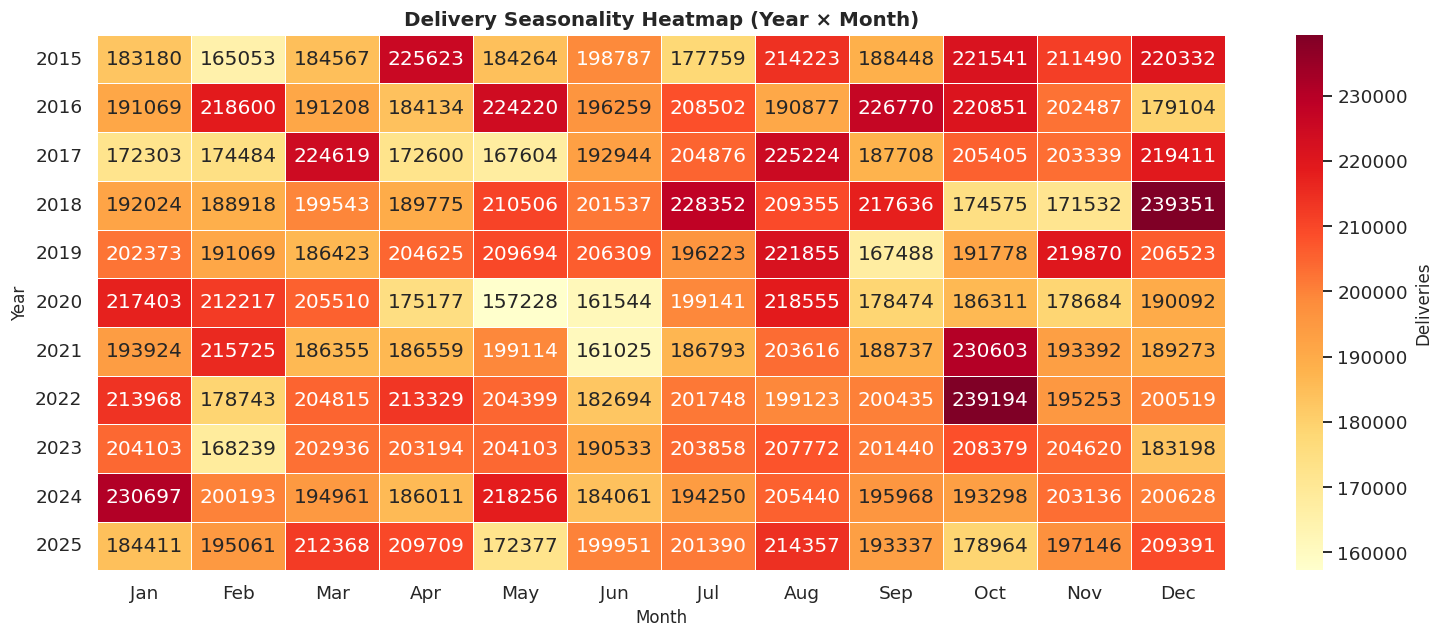

In [83]:
# Pivot: rows = Year, cols = Month - shows seasonal patterns clearly
pivot_season = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().unstack('Month')
pivot_season.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_season, annot=True, fmt='.0f', cmap='YlOrRd', # Yellow to Orange to Red
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Deliveries'})
ax.set_title('Delivery Seasonality Heatmap (Year × Month)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

### 2.4 Region-wise Deliveries

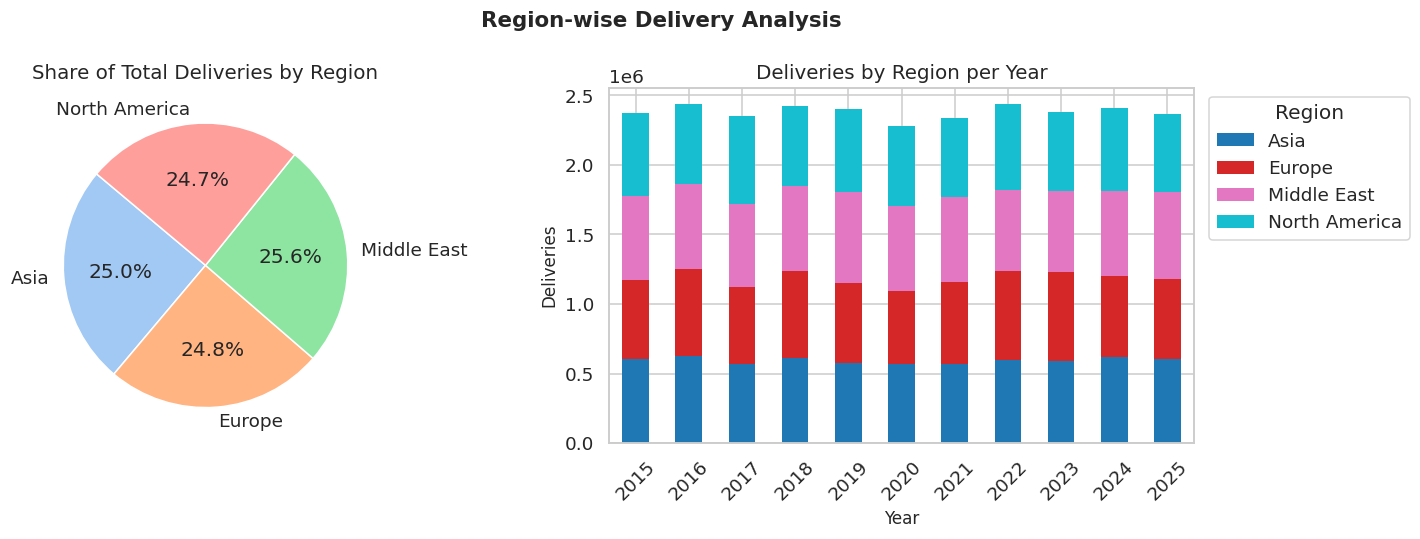

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total deliveries by region -> pie
region_total = df.groupby('Region')['Estimated_Deliveries'].sum()
axes[0].pie(region_total, labels=region_total.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('pastel'))
axes[0].set_title('Share of Total Deliveries by Region')

# Region deliveries over years -> stacked bar
region_year = df.groupby(['Year', 'Region'])['Estimated_Deliveries'].sum().unstack('Region')
region_year.plot(kind='bar', stacked=True, ax=axes[1],
                 colormap='tab10', edgecolor='none')
axes[1].set_title('Deliveries by Region per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Deliveries')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Region', bbox_to_anchor=(1.01, 1))

plt.suptitle('Region-wise Delivery Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Model-wise Performance

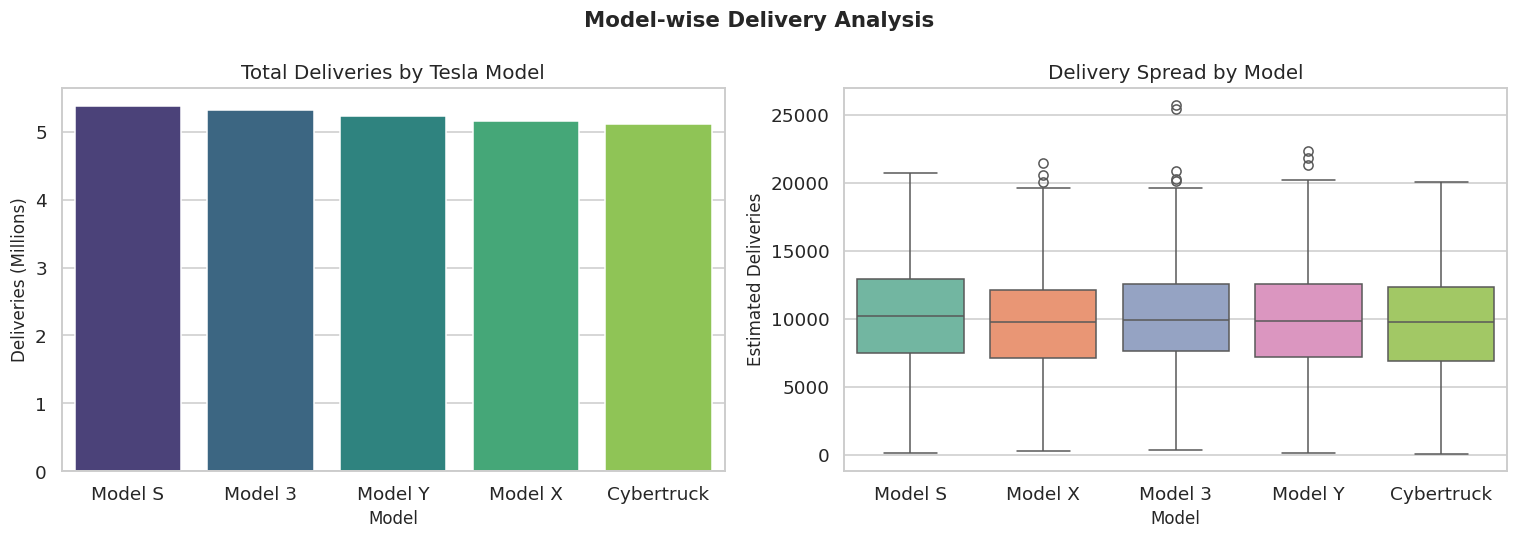

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total deliveries per model
model_total = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
sns.barplot(x=model_total.index, y=model_total.values / 1e6,
            palette='viridis', ax=axes[0])
axes[0].set_title('Total Deliveries by Tesla Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Deliveries (Millions)')

# Boxplot - delivery spread per model
sns.boxplot(data=df, x='Model', y='Estimated_Deliveries',
            palette='Set2', ax=axes[1])
axes[1].set_title('Delivery Spread by Model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Estimated Deliveries')

plt.suptitle('Model-wise Delivery Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Production vs Deliveries

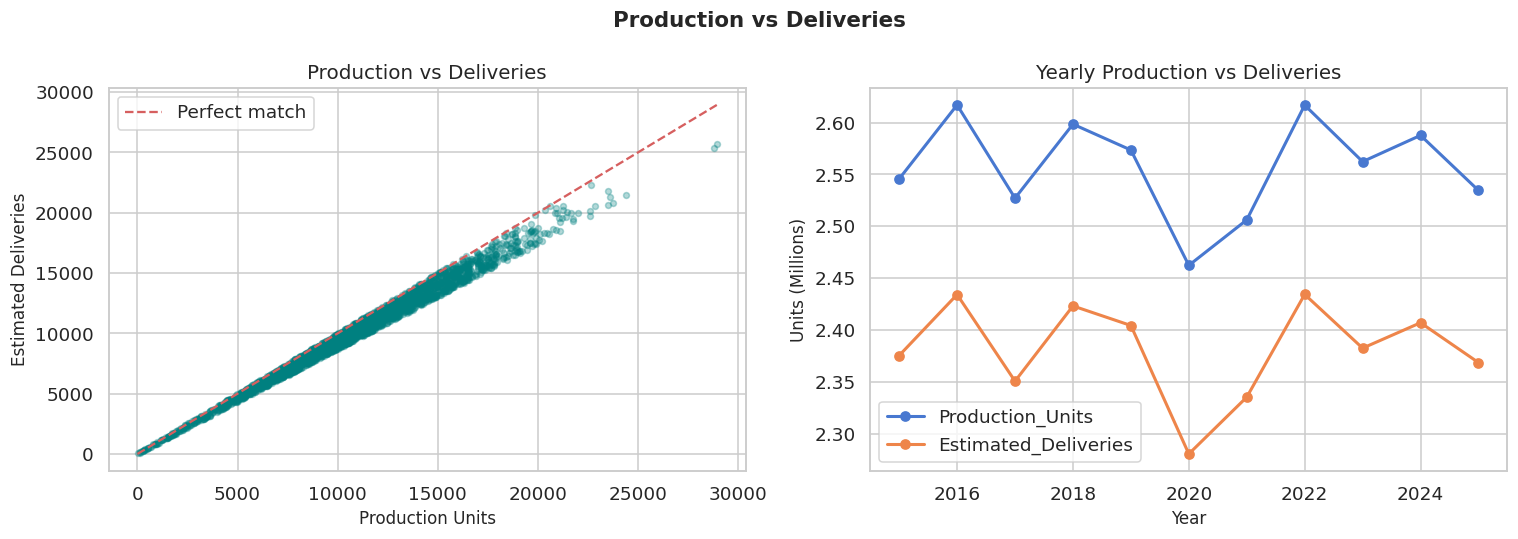

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: how closely do production and deliveries track?
axes[0].scatter(df['Production_Units'], df['Estimated_Deliveries'],
                alpha=0.3, color='teal', s=15)

# Perfect correlation reference line
lim = max(df['Production_Units'].max(), df['Estimated_Deliveries'].max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect match')
axes[0].set_title('Production vs Deliveries')
axes[0].set_xlabel('Production Units')
axes[0].set_ylabel('Estimated Deliveries')
axes[0].legend()

# Yearly aggregated production vs deliveries
pv = df.groupby('Year')[['Production_Units', 'Estimated_Deliveries']].sum() / 1e6
pv.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Yearly Production vs Deliveries')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Units (Millions)')

plt.suptitle('Production vs Deliveries', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 Price vs Deliveries

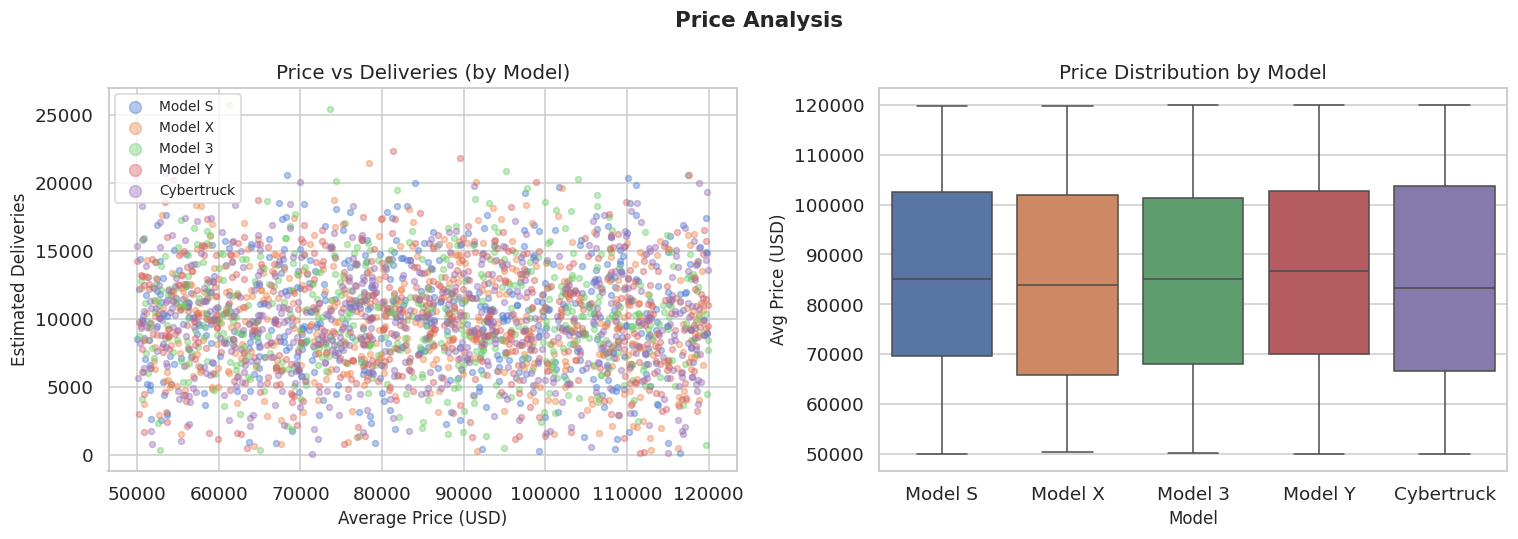

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter coloured by Model
for model in df['Model'].unique():
    sub = df[df['Model'] == model]
    axes[0].scatter(sub['Avg_Price_USD'], sub['Estimated_Deliveries'],
                    label=model, alpha=0.4, s=15)
axes[0].set_title('Price vs Deliveries (by Model)')
axes[0].set_xlabel('Average Price (USD)')
axes[0].set_ylabel('Estimated Deliveries')
axes[0].legend(markerscale=2, fontsize=9)

# Boxplot of price by model
sns.boxplot(data=df, x='Model', y='Avg_Price_USD', palette='deep', ax=axes[1])
axes[1].set_title('Price Distribution by Model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Avg Price (USD)')

plt.suptitle('Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.8 CO2 Savings & Charging Infrastructure

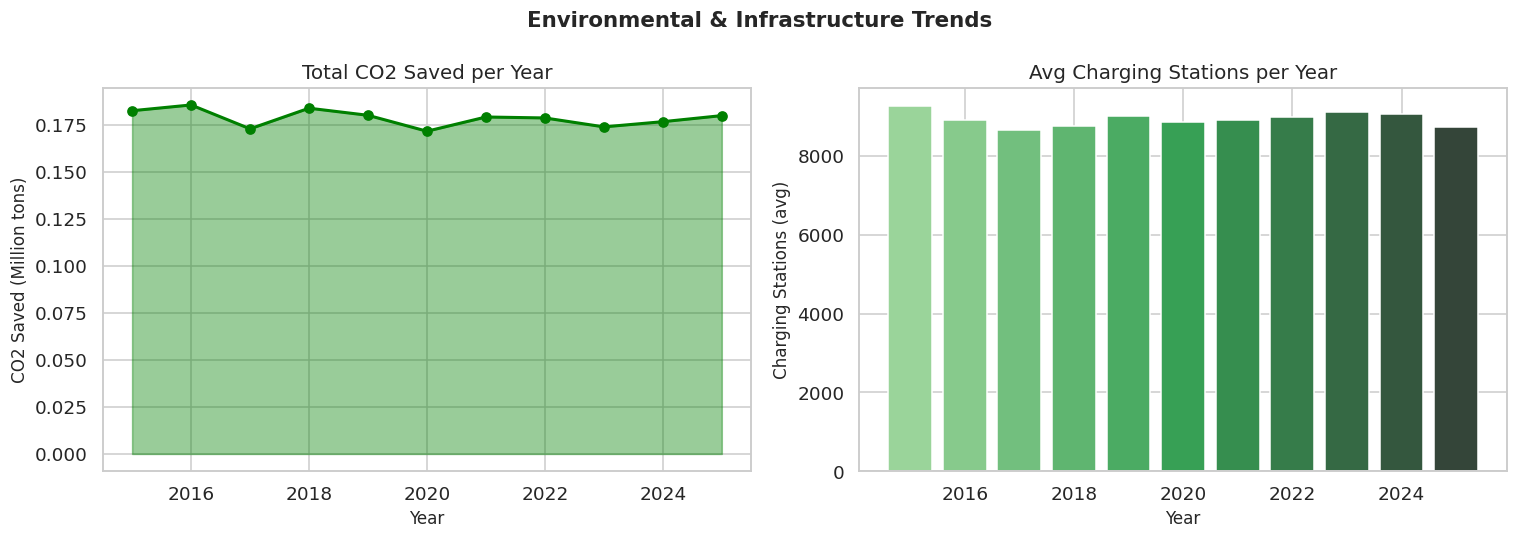

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CO2 saved over years
co2_yr = df.groupby('Year')['CO2_Saved_tons'].sum() / 1e6
axes[0].fill_between(co2_yr.index, co2_yr.values, alpha=0.4, color='green')
axes[0].plot(co2_yr.index, co2_yr.values, marker='o', color='green', linewidth=2)
axes[0].set_title('Total CO2 Saved per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('CO2 Saved (Million tons)')

# Charging stations growth
cs_yr = df.groupby('Year')['Charging_Stations'].mean()
axes[1].bar(cs_yr.index, cs_yr.values,
            color=sns.color_palette('Greens_d', len(cs_yr)))
axes[1].set_title('Avg Charging Stations per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Charging Stations (avg)')

plt.suptitle('Environmental & Infrastructure Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.9 Correlation Heatmap

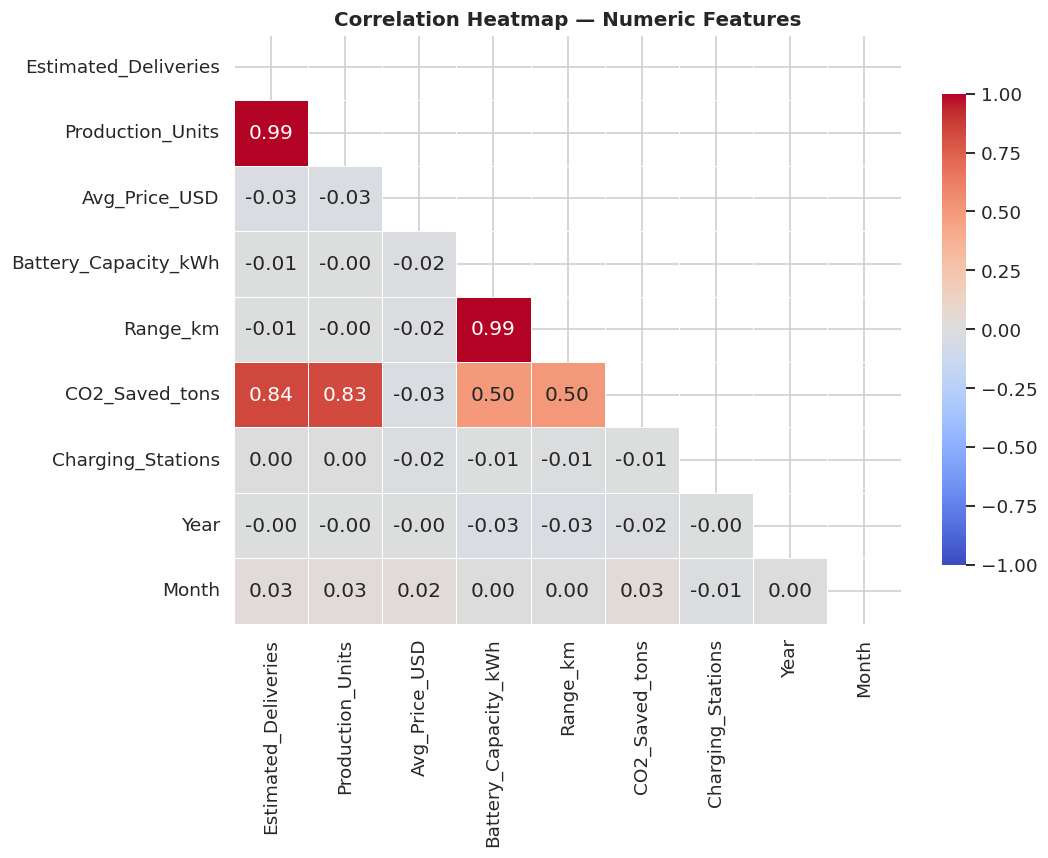

In [89]:
# Select numeric columns for correlation
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
            'Charging_Stations', 'Year', 'Month']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.10 Clustermap — Feature Relationships

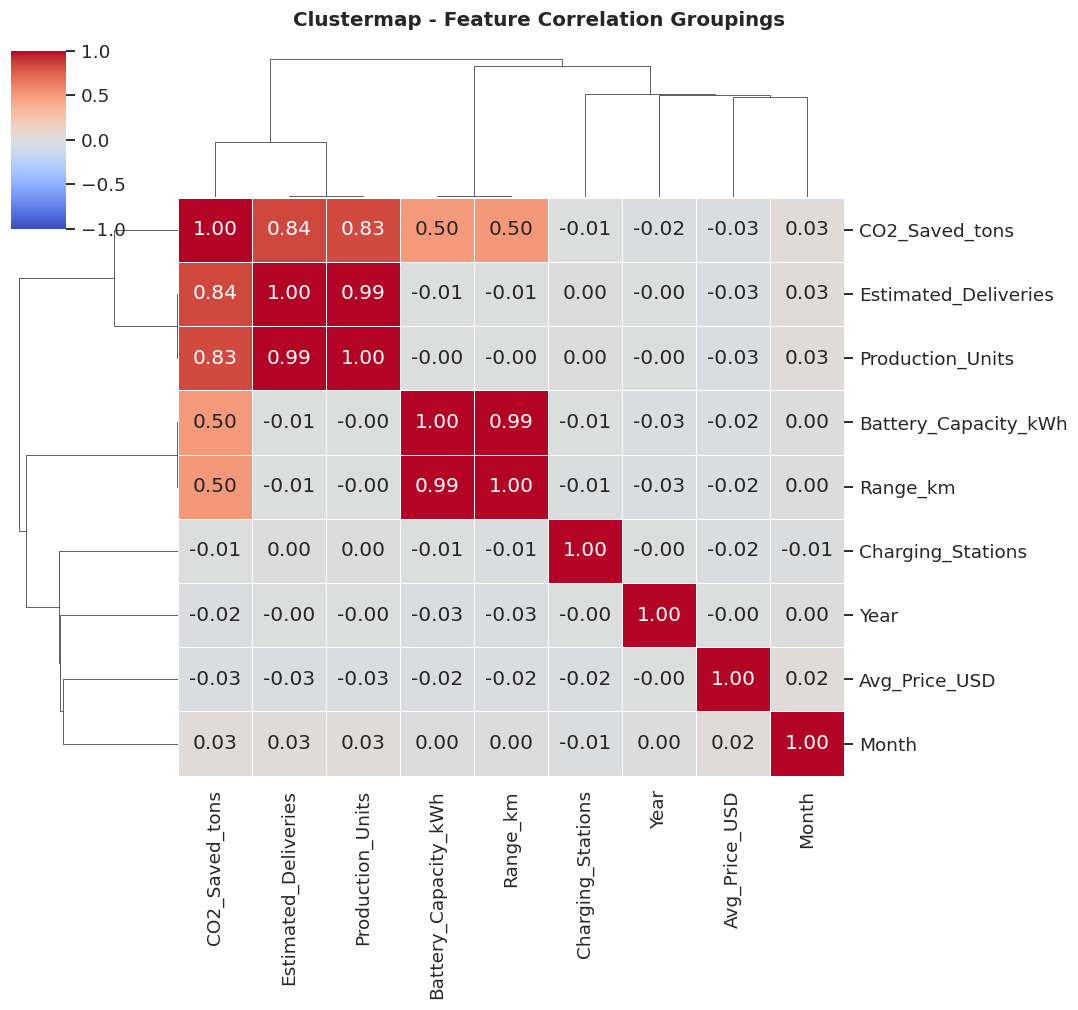

In [90]:
# Clustermap hierarchically clusters both rows and columns
# revealing which features naturally group together
cg = sns.clustermap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                    vmin=-1, vmax=1, center=0, figsize=(10, 9),
                    linewidths=0.4)
cg.fig.suptitle('Clustermap - Feature Correlation Groupings',
                fontsize=13, fontweight='bold', y=1.02)
plt.show()

## Section 3 — Feature Engineering

In [91]:
# A copy so the original EDA data stays clean
dff = df.copy()

# 1. Quarter 
dff['Quarter'] = dff['Date'].dt.quarter

# 2. Cyclic month encoding 
# sin/cos prevents the model from thinking Dec and Jan are far apart
dff['Month_sin'] = np.sin(2 * np.pi * dff['Month'] / 12)
dff['Month_cos'] = np.cos(2 * np.pi * dff['Month'] / 12)

# 3. Delivery-to-production ratio 
# Values < 1 mean not all produced units were delivered
dff['Delivery_Ratio'] = dff['Estimated_Deliveries'] / dff['Production_Units']

# 4. Price per km of range
# Efficiency proxy: how much does each km of range cost?
dff['Price_per_km'] = dff['Avg_Price_USD'] / dff['Range_km']

# 5. CO2 per delivery
dff['CO2_per_delivery'] = dff['CO2_Saved_tons'] / dff['Estimated_Deliveries']

# 6. Charging density 
# Higher stations per delivery implies more infrastructure support
dff['Charging_density'] = dff['Charging_Stations'] / dff['Estimated_Deliveries']

print('New features created:')
new_feats = ['Quarter','Month_sin','Month_cos','Delivery_Ratio',
             'Price_per_km','CO2_per_delivery','Charging_density']
dff[new_feats].describe().round(3)

New features created:


,Quarter,Month_sin,Month_cos,Delivery_Ratio,Price_per_km,CO2_per_delivery,Charging_density
count,2640.000,2640.000,2640.000,2640.000,2640.000,2640.000,2640.000
mean,2.500,-0.000,-0.000,0.933,180.046,0.075,1.476
std,1.118,0.707,0.707,0.037,61.894,0.018,6.146
min,1.000,-1.000,-1.000,0.870,69.902,0.049,0.162
25%,1.750,-0.592,-0.592,0.900,132.532,0.063,0.597
50%,2.500,-0.000,-0.000,0.932,170.357,0.071,0.899
75%,3.250,0.592,0.592,0.964,219.097,0.088,1.348
max,4.000,1.000,1.000,1.000,359.378,0.108,230.625


In [92]:
# 7. Lag features & Rolling averages
# Sort by Date before computing lags 
dff = dff.sort_values(['Region', 'Model', 'Date']).reset_index(drop=True)

grp = dff.groupby(['Region', 'Model'])['Estimated_Deliveries']

# Lag 1, 3, 6 months - past delivery values as predictors
dff['Lag_1']  = grp.shift(1)
dff['Lag_3']  = grp.shift(3)
dff['Lag_6']  = grp.shift(6)

# Rolling 3- and 6-month averages — smoothed recent trend
dff['Roll_3'] = grp.shift(1).transform(lambda x: x.rolling(3, min_periods=1).mean())
dff['Roll_6'] = grp.shift(1).transform(lambda x: x.rolling(6, min_periods=1).mean())

print(f'Rows before dropping NaN from lags: {len(dff)}')
dff = dff.dropna(subset=['Lag_1', 'Lag_3', 'Lag_6']).reset_index(drop=True)
print(f'Rows after dropping NaN from lags:  {len(dff)}')

Rows before dropping NaN from lags: 2640
Rows after dropping NaN from lags:  2520


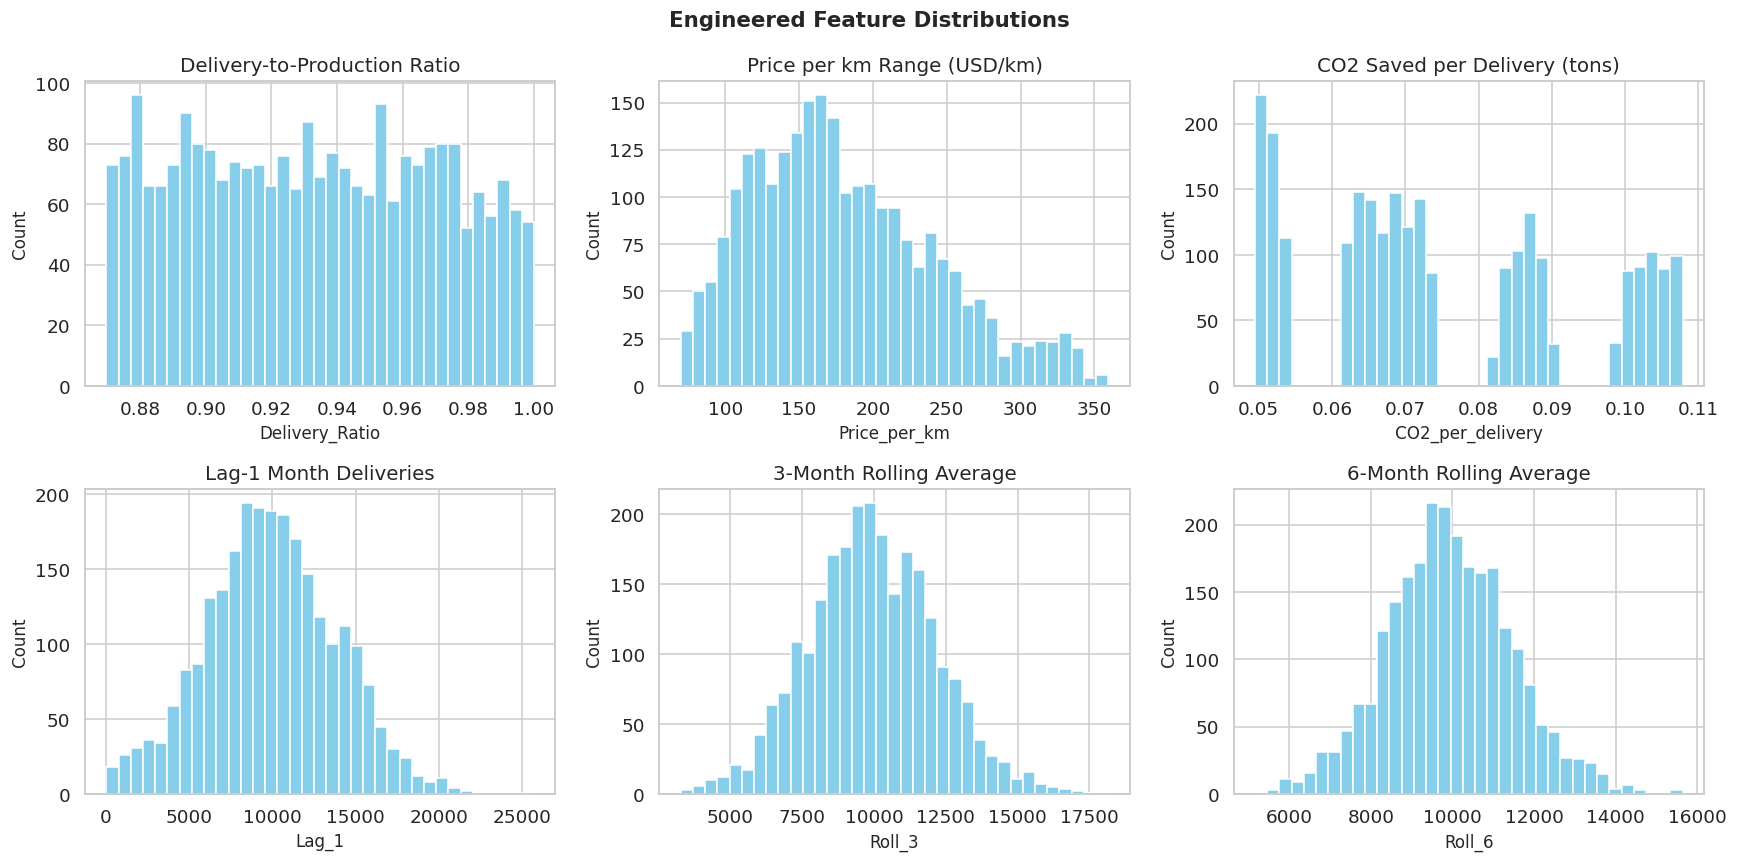

In [93]:
# Visualise engineered features 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

feat_plots = [
    ('Delivery_Ratio',   'Delivery-to-Production Ratio'),
    ('Price_per_km',     'Price per km Range (USD/km)'),
    ('CO2_per_delivery', 'CO2 Saved per Delivery (tons)'),
    ('Lag_1',            'Lag-1 Month Deliveries'),
    ('Roll_3',           '3-Month Rolling Average'),
    ('Roll_6',           '6-Month Rolling Average'),
]

for ax, (col, title) in zip(axes, feat_plots):
    ax.hist(dff[col].dropna(), bins=35, color='skyblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Engineered Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4 - Regression Modeling

### 4.1 Linear Regression

In [94]:
# Feature set for regression
FEATURES = [
    'Year', 'Month_sin', 'Month_cos', 'Quarter',
    'Region_enc', 'Model_enc', 'Source_Type_enc',
    'Production_Units', 'Avg_Price_USD',
    'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Charging_Stations',
    'Delivery_Ratio', 'Price_per_km',
    'CO2_per_delivery', 'Charging_density',
    'Lag_1', 'Lag_3', 'Lag_6', 'Roll_3', 'Roll_6'
]
TARGET = 'Estimated_Deliveries'

X = dff[FEATURES]
y = dff[TARGET]

# Time-ordered split — use last 20% as test (no shuffling for time series)
split_idx = int(len(dff) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 2016 | Test size: 504


In [95]:
# Scale features for Linear Regression
# LR is sensitive to feature scale; tree models are not
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Train Linear Regression 
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

def evaluate(name, y_true, y_pred):
    """Print and return RMSE, MAE, R^2 for a model."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{name:<30} | RMSE: {rmse:>8.1f} | MAE: {mae:>8.1f} | R^2: {r2:.4f}')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R^2': r2}

results = []
results.append(evaluate('Linear Regression (Baseline)', y_test, lr_pred))

Linear Regression (Baseline)   | RMSE:    151.5 | MAE:    104.5 | R^2: 0.9985


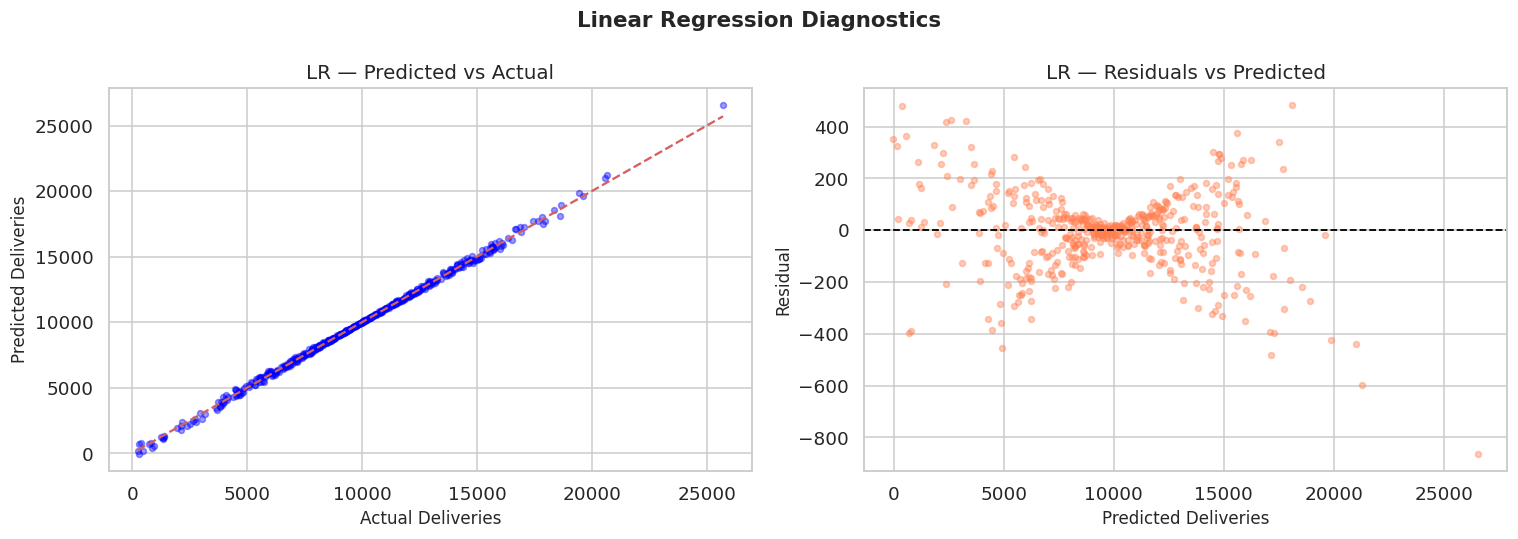

In [96]:
# Residual plot for Linear Regression
lr_resid = y_test - lr_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, lr_pred, alpha=0.4, s=15, color='blue')
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_title('LR — Predicted vs Actual')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')

# Residuals
axes[1].scatter(lr_pred, lr_resid, alpha=0.4, s=15, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_title('LR — Residuals vs Predicted')
axes[1].set_xlabel('Predicted Deliveries')
axes[1].set_ylabel('Residual')

plt.suptitle('Linear Regression Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Section 5 — Tree-Based Models
> *Random Forest and XGBoost - added for comparison and deeper insight.*

In [97]:
# Random Forest 
rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results.append(evaluate('Random Forest', y_test, rf_pred))

# XGBoost (untuned)
xgb_base = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1,
                             random_state=SEED, verbosity=0)
xgb_base.fit(X_train, y_train)
xgb_pred = xgb_base.predict(X_test)
results.append(evaluate('XGBoost (Untuned)', y_test, xgb_pred))

Random Forest                  | RMSE:    240.4 | MAE:     68.3 | R^2: 0.9962
XGBoost (Untuned)              | RMSE:    266.2 | MAE:     64.8 | R^2: 0.9953


## Section 6 - Hyperparameter Tuning: Ridge, Lasso, ElasticNet

> Regularised linear models constrain coefficient magnitude to reduce overfitting.  
> - **Ridge (L2):** shrinks all coefficients, none to zero  
> - **Lasso (L1):** can zero-out irrelevant features (automatic feature selection)  
> - **ElasticNet (L1 + L2):** combines both - useful when features are correlated
>
> We tune **alpha** (regularisation strength) and for ElasticNet also **l1_ratio**, using `GridSearchCV` with 5-fold CV.

In [98]:
# Shared alpha grid 
# Logarithmic spacing from very weak (0.001) to very strong (1000) regularisation
alpha_grid = np.logspace(-3, 3, 30)

CV_FOLDS   = 5
SCORING    = 'neg_root_mean_squared_error'

# 6.1 Ridge Regression 
ridge_gs = GridSearchCV(
    Ridge(),
    param_grid={'alpha': alpha_grid},
    cv=CV_FOLDS,
    scoring=SCORING,
    n_jobs=-1
)
ridge_gs.fit(X_train_sc, y_train)
best_ridge = ridge_gs.best_estimator_
ridge_pred = best_ridge.predict(X_test_sc)

print(f'Ridge  -> best alpha = {ridge_gs.best_params_["alpha"]:.4f}  '
      f'| CV RMSE = {-ridge_gs.best_score_:.1f}')
results.append(evaluate('Ridge (Tuned)', y_test, ridge_pred))

Ridge  -> best alpha = 0.0010  | CV RMSE = 157.6
Ridge (Tuned)                  | RMSE:    151.3 | MAE:    104.7 | R^2: 0.9985


In [99]:
# 6.2 Lasso Regression
lasso_gs = GridSearchCV(
    Lasso(max_iter=50_000),
    param_grid={'alpha': alpha_grid},
    cv=CV_FOLDS,
    scoring=SCORING,
    n_jobs=-1
)
lasso_gs.fit(X_train_sc, y_train)
best_lasso = lasso_gs.best_estimator_
lasso_pred = best_lasso.predict(X_test_sc)

# How many features did Lasso zero out?
n_zero = (best_lasso.coef_ == 0).sum()
print(f'Lasso  -> best alpha = {lasso_gs.best_params_["alpha"]:.4f}  '
      f'| CV RMSE = {-lasso_gs.best_score_:.1f}  '
      f'| Features zeroed out: {n_zero}/{len(FEATURES)}')
results.append(evaluate('Lasso (Tuned)', y_test, lasso_pred))

Lasso  -> best alpha = 2.0434  | CV RMSE = 157.0  | Features zeroed out: 8/22
Lasso (Tuned)                  | RMSE:    149.3 | MAE:    103.9 | R^2: 0.9985


In [100]:
# 6.3 ElasticNet Regression
l1_ratio_grid = [0.1, 0.25, 0.5, 0.75, 0.9]

enet_gs = GridSearchCV(
    ElasticNet(max_iter=50_000),
    param_grid={
        'alpha':    alpha_grid,
        'l1_ratio': l1_ratio_grid
    },
    cv=CV_FOLDS,
    scoring=SCORING,
    n_jobs=-1
)
enet_gs.fit(X_train_sc, y_train)
best_enet = enet_gs.best_estimator_
enet_pred = best_enet.predict(X_test_sc)

print(f'ElasticNet -> best alpha = {enet_gs.best_params_["alpha"]:.4f}  '
      f'| best l1_ratio = {enet_gs.best_params_["l1_ratio"]}  '
      f'| CV RMSE = {-enet_gs.best_score_:.1f}')
results.append(evaluate('ElasticNet (Tuned)', y_test, enet_pred))

ElasticNet -> best alpha = 0.0010  | best l1_ratio = 0.9  | CV RMSE = 157.6
ElasticNet (Tuned)             | RMSE:    151.4 | MAE:    104.7 | R^2: 0.9985


In [101]:
# 6.4 CV score comparison table (mean +- std) 
cv_summary = []
for name, gs in [('Ridge', ridge_gs), ('Lasso', lasso_gs), ('ElasticNet', enet_gs)]:
    best_idx  = gs.best_index_
    mean_rmse = -gs.cv_results_['mean_test_score'][best_idx]
    std_rmse  =  gs.cv_results_['std_test_score'][best_idx]
    cv_summary.append({'Model': name, 'CV Mean RMSE': mean_rmse, 'CV Std RMSE': std_rmse})

cv_df = pd.DataFrame(cv_summary).set_index('Model')
print('\n CV Score Comparison (best alpha) ')
print(cv_df.round(1).to_string())


 CV Score Comparison (best alpha) 
            CV Mean RMSE  CV Std RMSE
Model                                
Ridge              157.6         10.7
Lasso              157.0         10.6
ElasticNet         157.6         10.6


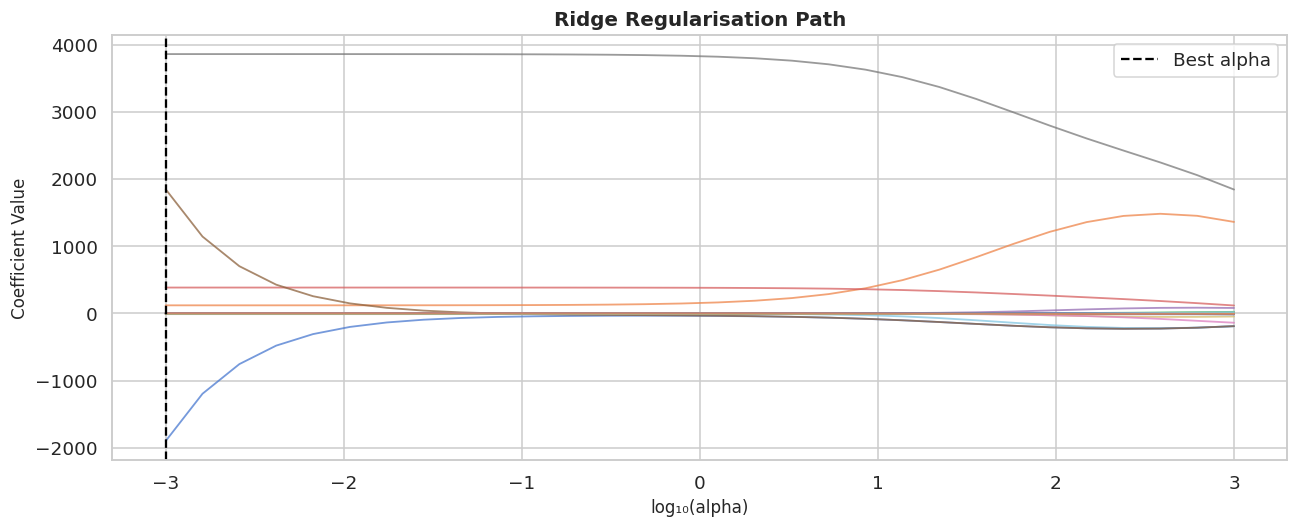

In [102]:
# 6.5 Regularisation path — Ridge 
# How do coefficients shrink as alpha increases?
coef_paths = []
for a in alpha_grid:
    m = Ridge(alpha=a).fit(X_train_sc, y_train)
    coef_paths.append(m.coef_)
coef_paths = np.array(coef_paths)

fig, ax = plt.subplots(figsize=(12, 5))
for i, feat in enumerate(FEATURES):
    ax.plot(np.log10(alpha_grid), coef_paths[:, i], linewidth=1.2, alpha=0.75)
ax.axvline(np.log10(ridge_gs.best_params_['alpha']),
           color='black', linestyle='--', linewidth=1.5, label='Best alpha')
ax.set_title('Ridge Regularisation Path', fontweight='bold')
ax.set_xlabel('log₁₀(alpha)')
ax.set_ylabel('Coefficient Value')
ax.legend()
plt.tight_layout()
plt.show()

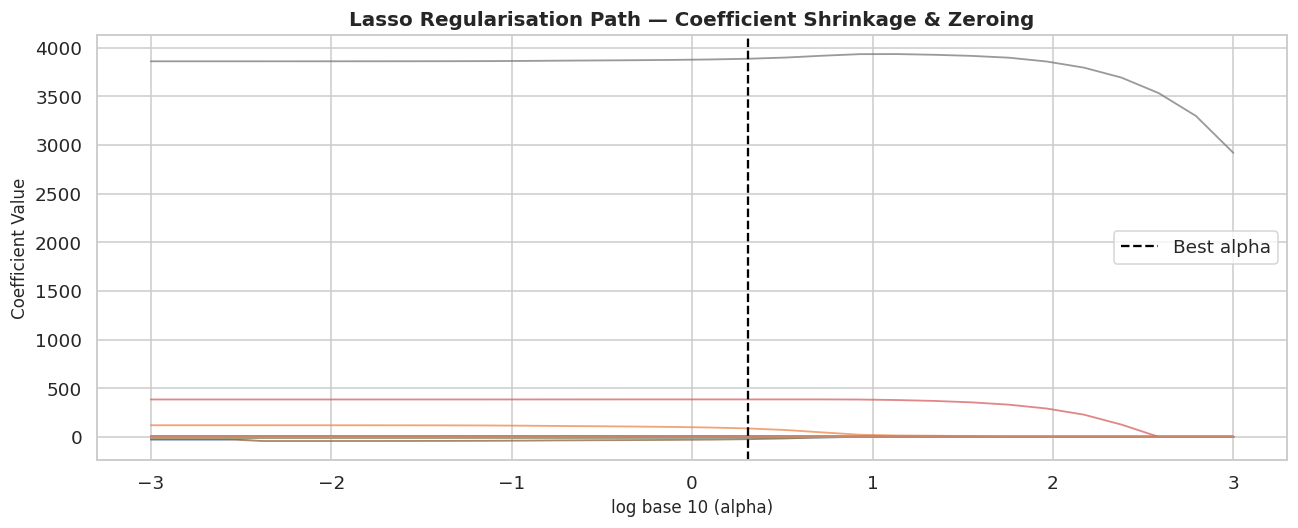

In [103]:
# 6.6 Lasso regularisation path 
lasso_paths = []
for a in alpha_grid:
    m = Lasso(alpha=a, max_iter=10_000).fit(X_train_sc, y_train)
    lasso_paths.append(m.coef_)
lasso_paths = np.array(lasso_paths)

fig, ax = plt.subplots(figsize=(12, 5))
for i, feat in enumerate(FEATURES):
    ax.plot(np.log10(alpha_grid), lasso_paths[:, i], linewidth=1.2, alpha=0.75)
ax.axvline(np.log10(lasso_gs.best_params_['alpha']),
           color='black', linestyle='--', linewidth=1.5, label='Best alpha')
ax.set_title('Lasso Regularisation Path — Coefficient Shrinkage & Zeroing',
             fontweight='bold')
ax.set_xlabel('log base 10 (alpha)')
ax.set_ylabel('Coefficient Value')
ax.legend()
plt.tight_layout()
plt.show()

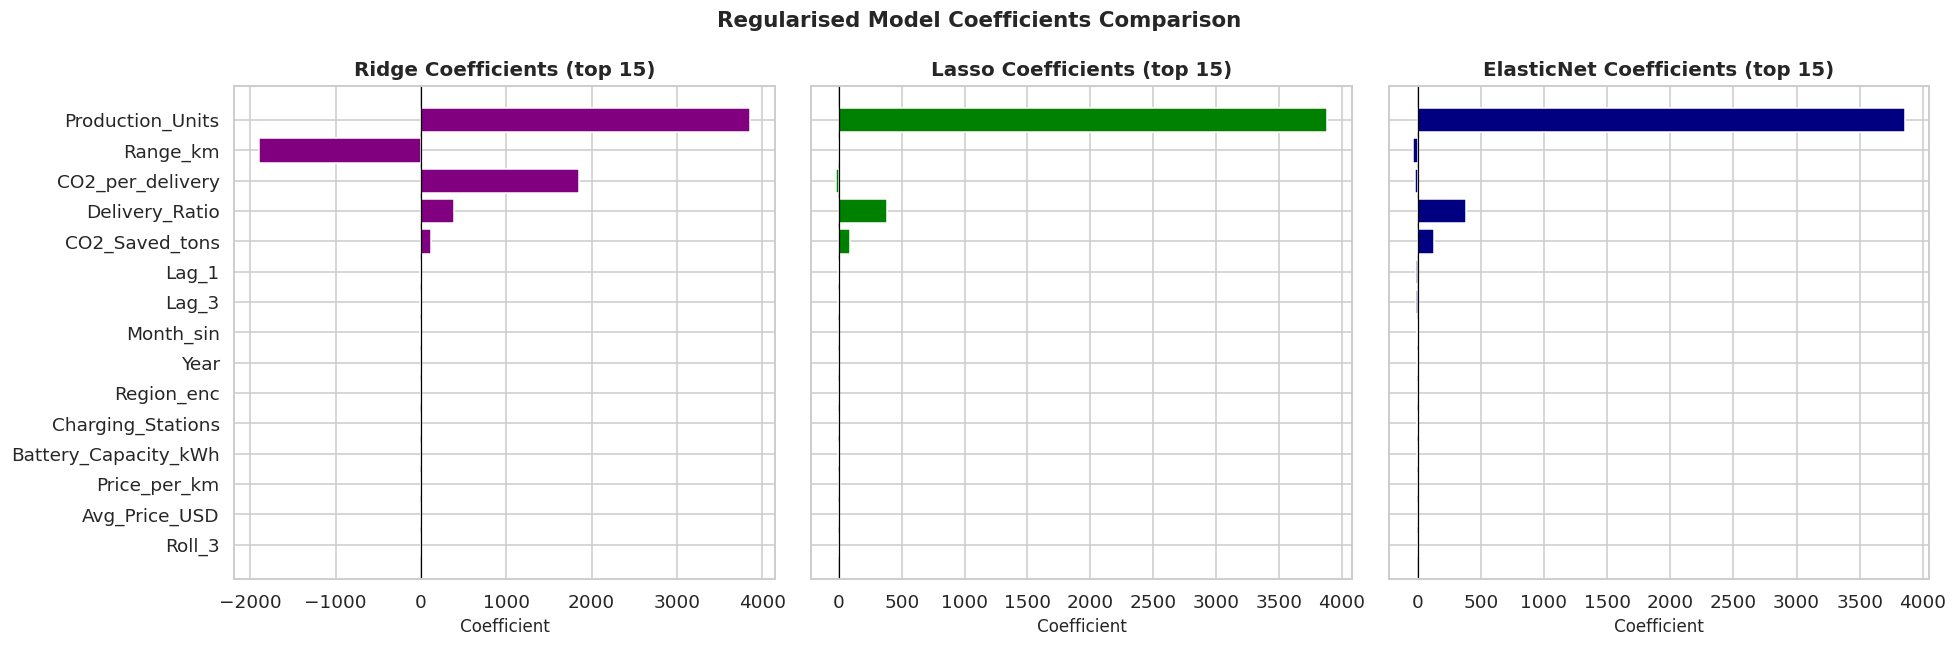

In [104]:
# 6.7 Coefficient comparison - Ridge vs Lasso vs ElasticNet 
coef_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Ridge':      best_ridge.coef_,
    'Lasso':      best_lasso.coef_,
    'ElasticNet': best_enet.coef_,
}).set_index('Feature').sort_values('Ridge', key=abs, ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
colors = ['purple', 'green', 'navy']

for ax, col, color in zip(axes, ['Ridge', 'Lasso', 'ElasticNet'], colors):
    subset = coef_df[col].head(top_n)
    bars = ax.barh(subset.index, subset.values, color=color, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{col} Coefficients (top {top_n})', fontweight='bold')
    ax.set_xlabel('Coefficient')
    ax.invert_yaxis()

plt.suptitle('Regularised Model Coefficients Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 All Models Comparison
                                 RMSE      MAE    R^2
Model                                                
Linear Regression (Baseline)  151.494  104.454  0.998
Random Forest                 240.449   68.274  0.996
XGBoost (Untuned)             266.192   64.848  0.995
Ridge (Tuned)                 151.263  104.718  0.998
Lasso (Tuned)                 149.306  103.862  0.999
ElasticNet (Tuned)            151.365  104.694  0.998


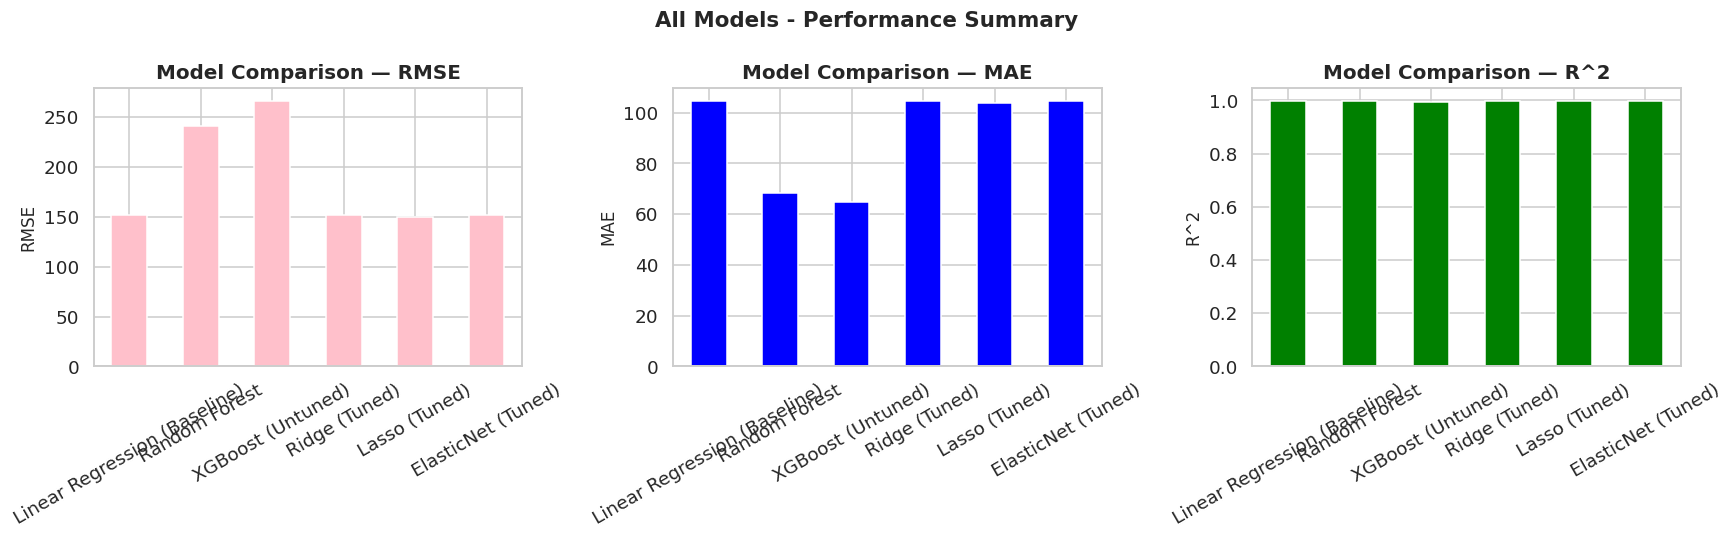

In [105]:
# 6.8 All-model performance bar chart
results_df = pd.DataFrame(results).set_index('Model')
print('\n All Models Comparison')
print(results_df.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'R^2']
colors  = ['pink', 'blue', 'green']

for ax, metric, color in zip(axes, metrics, colors):
    results_df[metric].plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Model Comparison — {metric}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('All Models - Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Section 7 — Time Series Forecasting: Linear Regression + Lag Features

> **Approach:** Aggregate monthly deliveries across all regions/models into a single time series.  
> Then create lag and rolling-mean features and train a standard `LinearRegression`.  
> Finally, forecast the next 12 months **recursively** - each prediction is fed back as a lag for the next step.
>
> **Features used:**  
> `Lag_1`, `Lag_2`, `Lag_3`, `RollingMean_3`, `RollingMean_6`  
> **Target:** `Deliveries`

In [106]:
# 7.1 Build monthly aggregate series 
monthly = (
    df.groupby('Date')['Estimated_Deliveries']
      .sum()
      .reset_index()
      .rename(columns={'Estimated_Deliveries': 'Deliveries'})
      .sort_values('Date')
      .reset_index(drop=True)
)

print(f'Monthly series: {len(monthly)} records')
print(f'  From: {monthly["Date"].min().date()}  ->  To: {monthly["Date"].max().date()}')
monthly.tail(6)

Monthly series: 132 records
  From: 2015-01-01  ->  To: 2025-12-01


,Date,Deliveries
126,2025-07-01,201390
127,2025-08-01,214357
128,2025-09-01,193337
129,2025-10-01,178964
130,2025-11-01,197146
131,2025-12-01,209391


In [107]:
# 7.2 Create lag & rolling features 
ts = monthly.copy()

ts['Lag_1']         = ts['Deliveries'].shift(1)
ts['Lag_2']         = ts['Deliveries'].shift(2)
ts['Lag_3']         = ts['Deliveries'].shift(3)
ts['RollingMean_3'] = ts['Deliveries'].shift(1).rolling(3).mean()
ts['RollingMean_6'] = ts['Deliveries'].shift(1).rolling(6).mean()

ts = ts.dropna().reset_index(drop=True)

TS_FEATURES = ['Lag_1', 'Lag_2', 'Lag_3', 'RollingMean_3', 'RollingMean_6']
Xts = ts[TS_FEATURES]
yts = ts['Deliveries']

print(f'Time series rows after lag creation: {len(ts)}')
ts[['Date'] + TS_FEATURES + ['Deliveries']].head(8)

Time series rows after lag creation: 126


,Date,Lag_1,Lag_2,Lag_3,RollingMean_3,RollingMean_6,Deliveries
0,2015-07-01,198787.0,184264.0,225623.0,202891.333333,190245.666667,177759
1,2015-08-01,177759.0,198787.0,184264.0,186936.666667,189342.166667,214223
2,2015-09-01,214223.0,177759.0,198787.0,196923.000000,197537.166667,188448
3,2015-10-01,188448.0,214223.0,177759.0,193476.666667,198184.000000,221541
4,2015-11-01,221541.0,188448.0,214223.0,208070.666667,197503.666667,211490
5,2015-12-01,211490.0,221541.0,188448.0,207159.666667,202041.333333,220332
6,2016-01-01,220332.0,211490.0,221541.0,217787.666667,205632.166667,191069
7,2016-02-01,191069.0,220332.0,211490.0,207630.333333,207850.500000,218600


In [108]:
# 7.3 Time-ordered 80/20 split & train 
ts_split = int(len(ts) * 0.8)
Xts_tr, Xts_te = Xts.iloc[:ts_split], Xts.iloc[ts_split:]
yts_tr, yts_te = yts.iloc[:ts_split], yts.iloc[ts_split:]
dates_te        = ts['Date'].iloc[ts_split:]

# Scale for linear regression
ts_scaler   = StandardScaler()
Xts_tr_sc   = ts_scaler.fit_transform(Xts_tr)
Xts_te_sc   = ts_scaler.transform(Xts_te)

lr_ts = LinearRegression()
lr_ts.fit(Xts_tr_sc, yts_tr)
ts_pred = lr_ts.predict(Xts_te_sc)

ts_rmse = np.sqrt(mean_squared_error(yts_te, ts_pred))
ts_mae  = mean_absolute_error(yts_te, ts_pred)
ts_r2   = r2_score(yts_te, ts_pred)

print(f'LR Time Series - Test RMSE: {ts_rmse:.1f} | MAE: {ts_mae:.1f} | R^2: {ts_r2:.4f}')

LR Time Series - Test RMSE: 12702.5 | MAE: 9803.4 | R^2: 0.0024


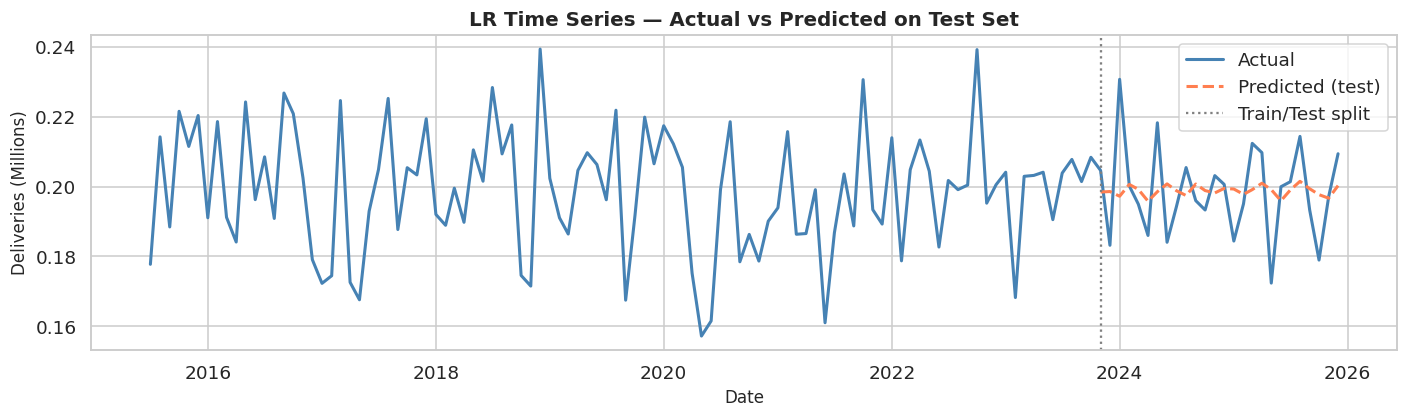

In [109]:
# 7.4 Test-period plot: Actual vs Predicted 
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts['Date'], ts['Deliveries'] / 1e6,
        color='steelblue', linewidth=2, label='Actual')
ax.plot(dates_te, ts_pred / 1e6,
        color='coral', linewidth=2, linestyle='--', label='Predicted (test)')
ax.axvline(ts['Date'].iloc[ts_split], color='gray',
           linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title('LR Time Series — Actual vs Predicted on Test Set', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Deliveries (Millions)')
ax.legend()
plt.tight_layout()
plt.show()

In [110]:
# 7.5 Recursive 12-month forecast
# Seed the rolling history with all actual values
history = list(ts['Deliveries'].values)
last_date = ts['Date'].max()

future_preds = []

for step in range(12):
    lag1 = history[-1]
    lag2 = history[-2]
    lag3 = history[-3]
    rm3  = np.mean(history[-3:])
    rm6  = np.mean(history[-6:])

    row_scaled = ts_scaler.transform([[lag1, lag2, lag3, rm3, rm6]])
    pred = lr_ts.predict(row_scaled)[0]
    pred = max(pred, 0)   # deliveries can't be negative

    future_preds.append(pred)
    history.append(pred)

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=12,
    freq='MS'
)

print('12-month recursive forecast (Deliveries):')
forecast_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_preds})
print(forecast_df.to_string(index=False))

12-month recursive forecast (Deliveries):
      Date      Forecast
2026-01-01 201320.817319
2026-02-01 198661.180163
2026-03-01 197639.445058
2026-04-01 198547.610979
2026-05-01 199038.572173
2026-06-01 199126.974794
2026-07-01 198940.073529
2026-08-01 198862.951680
2026-09-01 198862.012084
2026-10-01 198893.190177
2026-11-01 198904.532952
2026-12-01 198902.524773


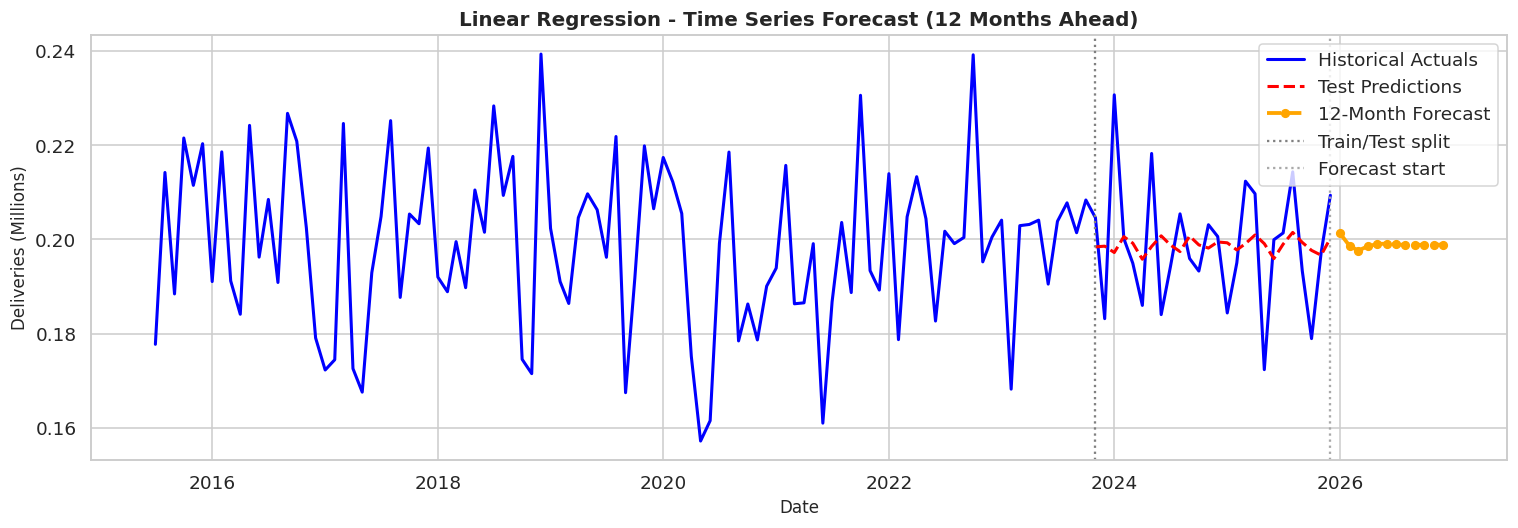

In [111]:
# 7.6 Full forecast plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ts['Date'], ts['Deliveries'] / 1e6,
        color='blue', linewidth=2, label='Historical Actuals')
ax.plot(dates_te, ts_pred / 1e6,
        color='red', linewidth=2, linestyle='--', label='Test Predictions')
ax.plot(future_dates, np.array(future_preds) / 1e6,
        color='orange', linewidth=2.5, linestyle='--', marker='o',
        markersize=5, label='12-Month Forecast')
ax.axvline(ts['Date'].iloc[ts_split], color='gray',
           linestyle=':', linewidth=1.5, label='Train/Test split')
ax.axvline(last_date, color='darkgray',
           linestyle=':', linewidth=1.5, label='Forecast start')

ax.set_title('Linear Regression - Time Series Forecast (12 Months Ahead)',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Deliveries (Millions)')
ax.legend()
plt.tight_layout()
plt.show()

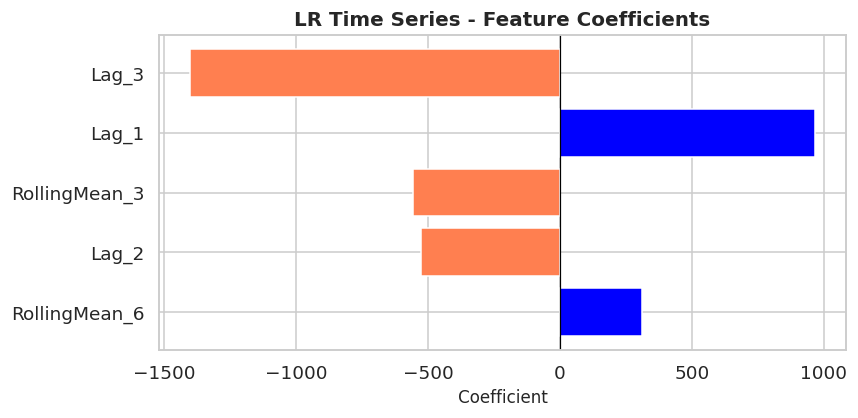

In [112]:
# 7.7 Feature coefficients — what drives the forecast?
ts_coef = pd.Series(lr_ts.coef_, index=TS_FEATURES).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ['coral' if v < 0 else 'blue' for v in ts_coef.values]
ax.barh(ts_coef.index, ts_coef.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('LR Time Series - Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Section 8 - Enhancement: Explainability
> *Coefficients (regularised models), Permutation Importance (LR), SHAP (XGBoost).*

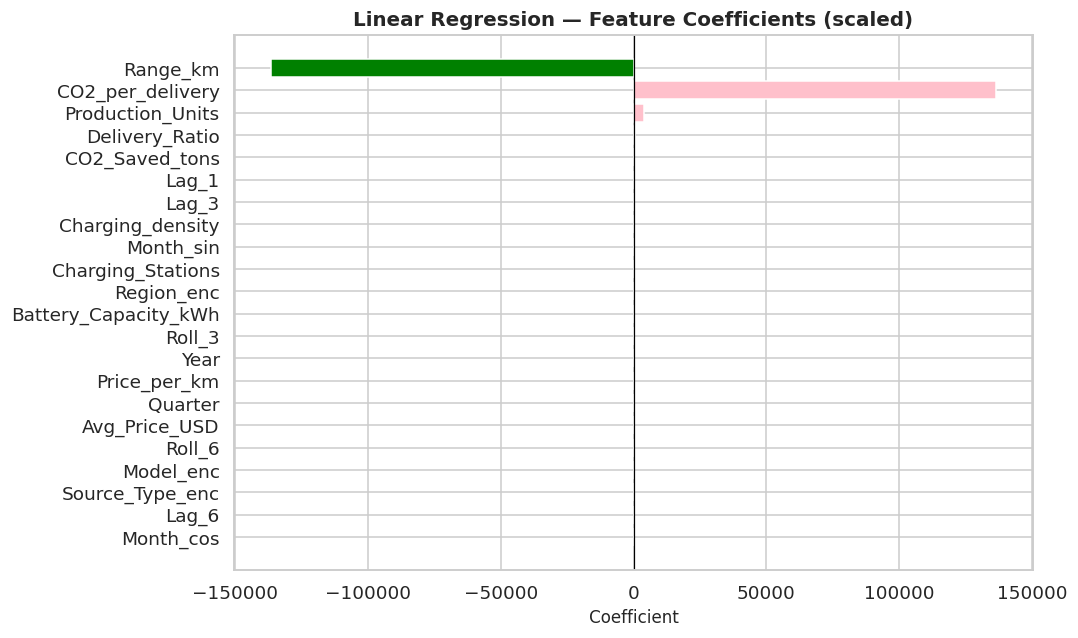

In [113]:
# 8.1 Linear Regression coefficients 
lr_coef = pd.Series(lr.coef_, index=FEATURES)
lr_coef_sorted = lr_coef.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['green' if lr_coef[f] < 0 else 'pink'
              for f in lr_coef_sorted.index]
ax.barh(lr_coef_sorted.index, lr_coef[lr_coef_sorted.index].values,
        color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression — Feature Coefficients (scaled)', fontweight='bold')
ax.set_xlabel('Coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

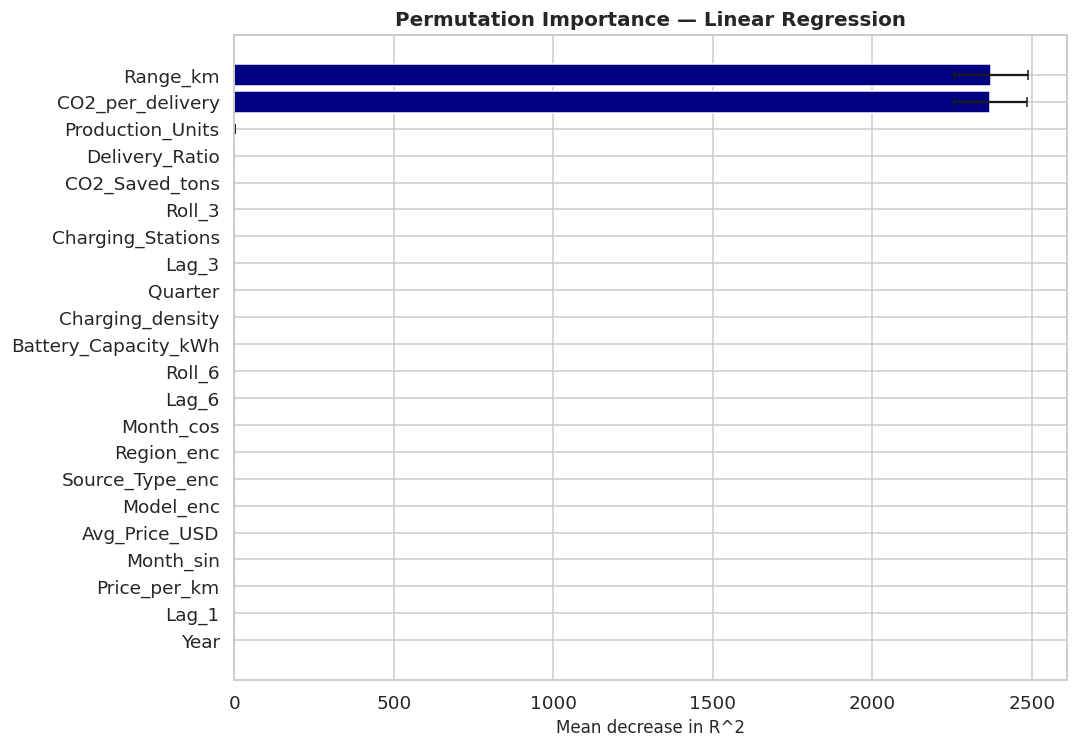

In [114]:
# 8.2 Permutation Importance - Linear Regression 
perm = permutation_importance(lr, X_test_sc, y_test,
                              n_repeats=20, random_state=SEED, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(perm_df['Feature'], perm_df['Importance'],
        xerr=perm_df['Std'], color='navy', edgecolor='white',
        capsize=3)
ax.set_title('Permutation Importance — Linear Regression', fontweight='bold')
ax.set_xlabel('Mean decrease in R^2')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [115]:
# 8.3 SHAP — XGBoost 
explainer   = shap.TreeExplainer(xgb_base)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (504, 22)


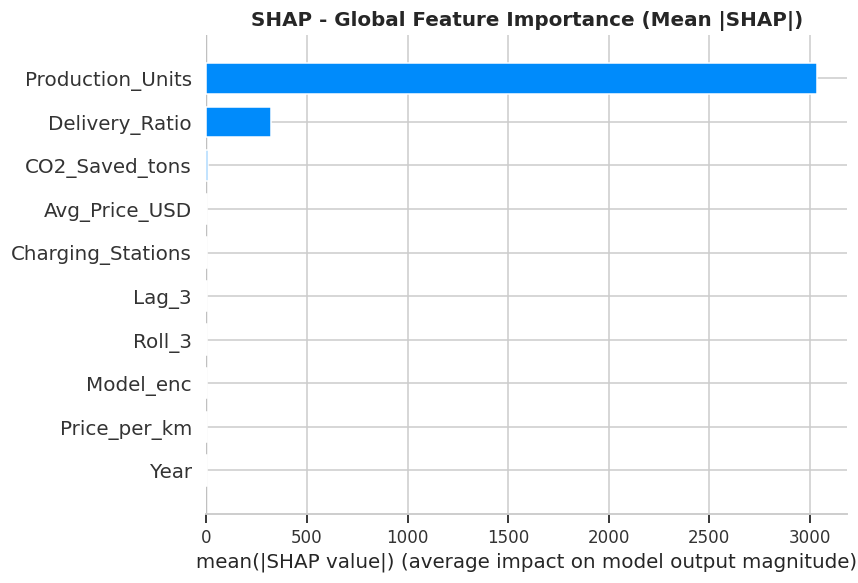

In [116]:
# Global importance bar plot
# Mean absolute SHAP value per feature = average impact on output
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  max_display=10, show=False)
plt.title('SHAP - Global Feature Importance (Mean |SHAP|)', fontweight='bold')
plt.tight_layout()
plt.show()

Top SHAP feature: Production_Units


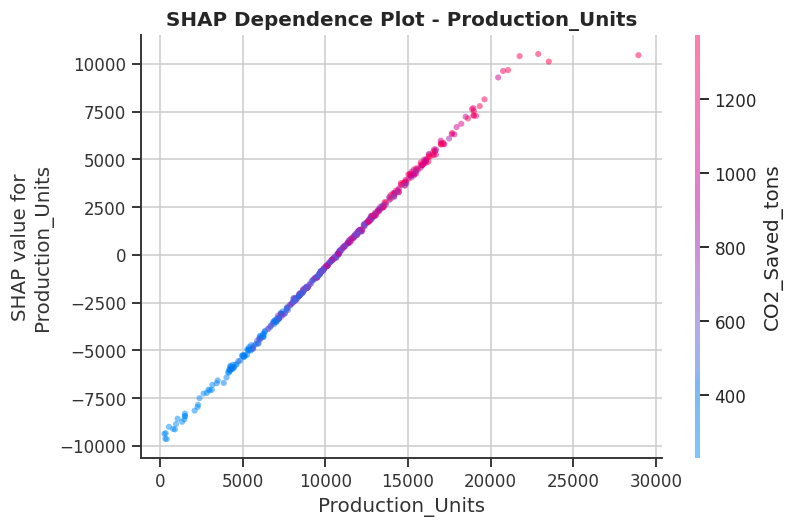

In [117]:
# Dependence plot - top feature
# Shows exactly how the top feature's value affects predictions
top_feature = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).idxmax()

print(f'Top SHAP feature: {top_feature}')
shap.dependence_plot(top_feature, shap_values, X_test,
                     show=False, alpha=0.5)
plt.title(f'SHAP Dependence Plot - {top_feature}', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 9 - Enhancement: Error Analysis
> *Where does the model fail? Broken down by Region and Tesla Model.*

In [118]:
# Attach predictions and errors back to test rows
test_df = dff.iloc[split_idx:].copy()
test_df['Predicted'] = xgb_pred
test_df['Error']     = test_df[TARGET] - test_df['Predicted']
test_df['Abs_Error'] = test_df['Error'].abs()
test_df['RMSE_row']  = test_df['Error'] ** 2  # will sqrt after groupby

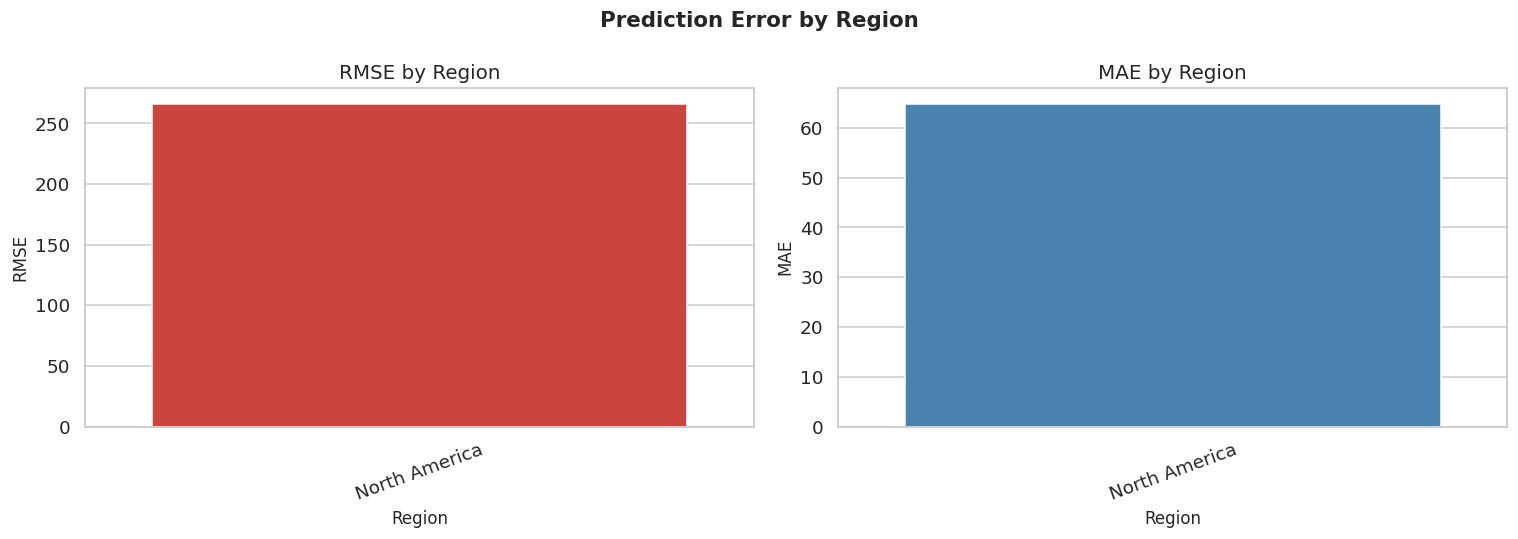

In [119]:
# Error by Region
region_err = test_df.groupby('Region').agg(
    RMSE=('RMSE_row', lambda x: np.sqrt(x.mean())),
    MAE=('Abs_Error', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=region_err, x='Region', y='RMSE', palette='Reds_d', ax=axes[0])
axes[0].set_title('RMSE by Region')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=region_err, x='Region', y='MAE', palette='Blues_d', ax=axes[1])
axes[1].set_title('MAE by Region')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Prediction Error by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

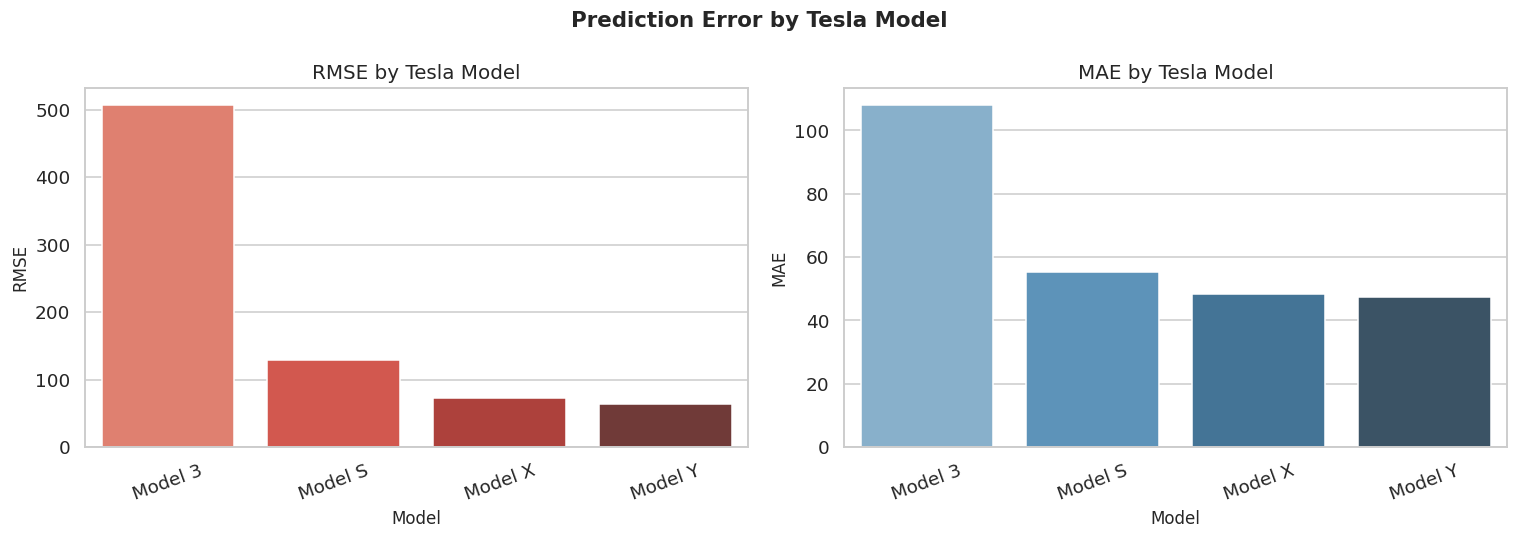

In [120]:
# Error by Tesla Model
model_err = test_df.groupby('Model').agg(
    RMSE=('RMSE_row', lambda x: np.sqrt(x.mean())),
    MAE=('Abs_Error', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=model_err, x='Model', y='RMSE', palette='Reds_d', ax=axes[0])
axes[0].set_title('RMSE by Tesla Model')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=model_err, x='Model', y='MAE', palette='Blues_d', ax=axes[1])
axes[1].set_title('MAE by Tesla Model')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Prediction Error by Tesla Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

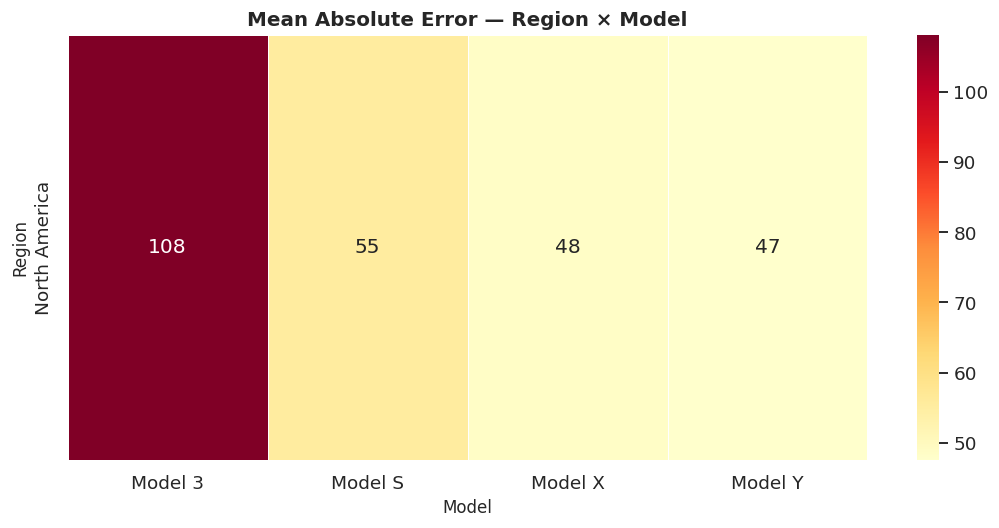

In [121]:
# Region × Model error heatmap
pivot_err = test_df.pivot_table(
    index='Region', columns='Model', values='Abs_Error', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_err, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax)
ax.set_title('Mean Absolute Error — Region × Model', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 10 - Enhancement: Trend Analysis (2015–2020 vs 2021–2025)
> *Has the product meaningfully changed over a decade?*

In [122]:
# Split into two eras
era_a = df[df['Year'] <= 2020].copy()
era_b = df[df['Year'] >= 2021].copy()

def era_stats(df_era, label):
    print(f'\n {label}')
    print(f'  Avg Price:            ${df_era["Avg_Price_USD"].mean():,.0f}')
    print(f'  Avg Battery (kWh):    {df_era["Battery_Capacity_kWh"].mean():.1f}')
    print(f'  Avg Range (km):       {df_era["Range_km"].mean():.1f}')
    print(f'  Avg CO2 Saved (tons): {df_era["CO2_Saved_tons"].mean():.1f}')
    print(f'  Total Deliveries:     {df_era["Estimated_Deliveries"].sum():,}')

era_stats(era_a, '2015–2020 (Early era)')
era_stats(era_b, '2021–2025 (Recent era)')


 2015–2020 (Early era)
  Avg Price:            $84,973
  Avg Battery (kWh):    87.6
  Avg Range (km):       503.2
  Avg CO2 Saved (tons): 747.4
  Total Deliveries:     14,267,535

 2021–2025 (Recent era)
  Avg Price:            $84,829
  Avg Battery (kWh):    86.4
  Avg Range (km):       496.7
  Avg CO2 Saved (tons): 740.1
  Total Deliveries:     11,927,072


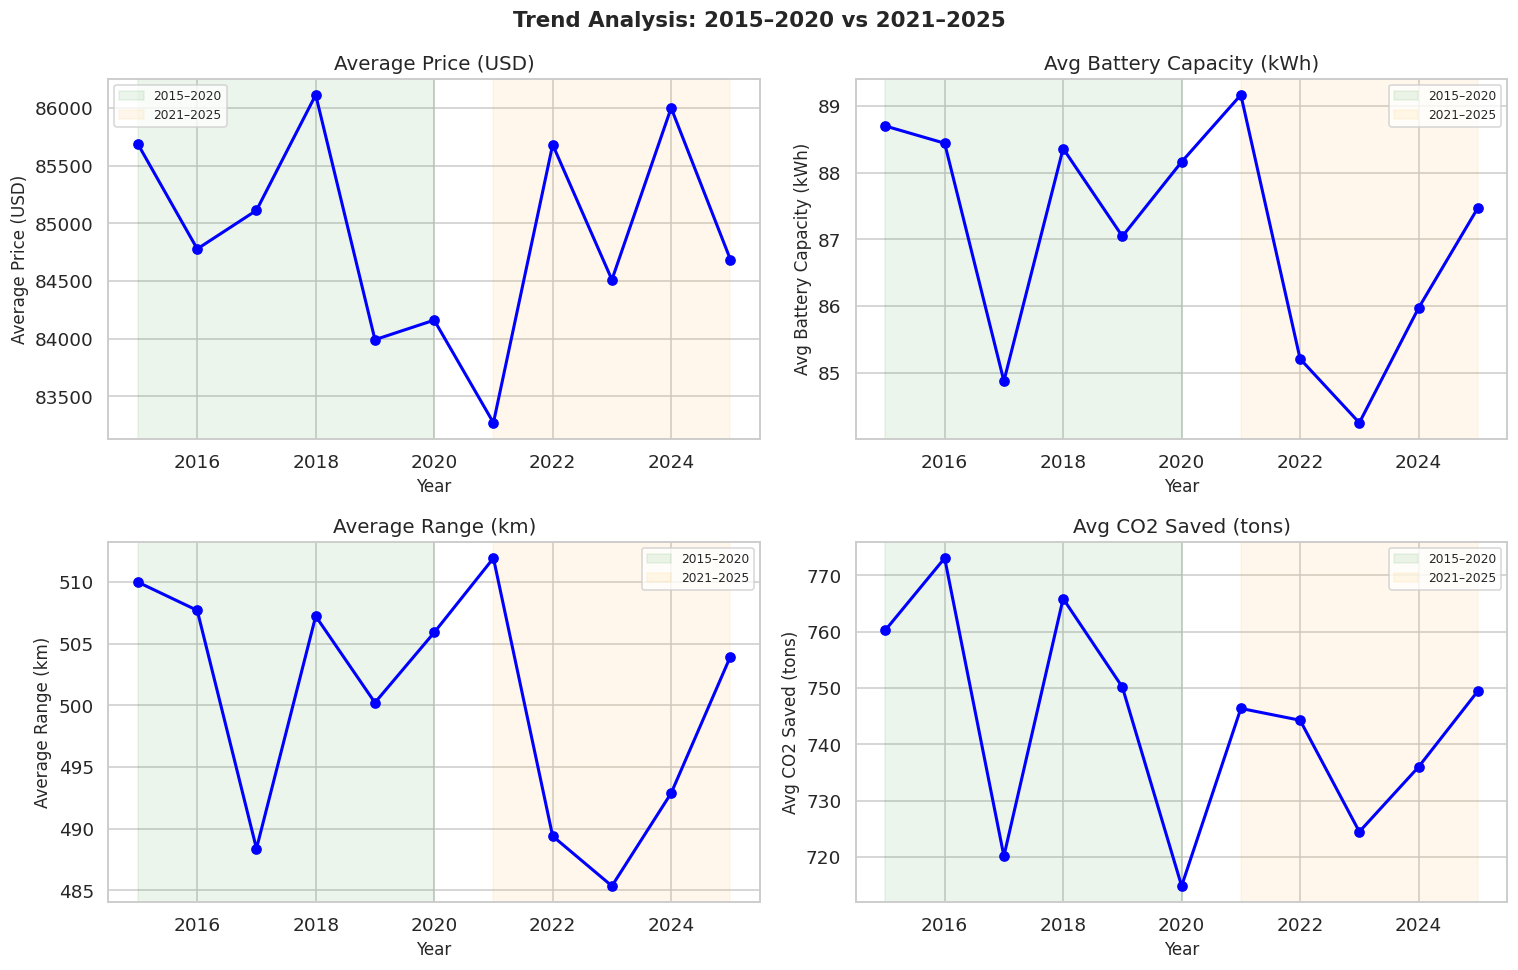

In [123]:
# Trend plots for 4 key metrics 
trend_metrics = {
    'Avg_Price_USD':          'Average Price (USD)',
    'Battery_Capacity_kWh':   'Avg Battery Capacity (kWh)',
    'Range_km':               'Average Range (km)',
    'CO2_Saved_tons':         'Avg CO2 Saved (tons)',
}

yearly_trend = df.groupby('Year')[list(trend_metrics.keys())].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, trend_metrics.items()):
    ax.plot(yearly_trend.index, yearly_trend[col],
            marker='o', linewidth=2, color='blue')
    # shade the two eras
    ax.axvspan(2015, 2020, alpha=0.08, color='green',  label='2015–2020')
    ax.axvspan(2021, 2025, alpha=0.08, color='orange', label='2021–2025')
    ax.set_title(label)
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.legend(fontsize=8)

plt.suptitle('Trend Analysis: 2015–2020 vs 2021–2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

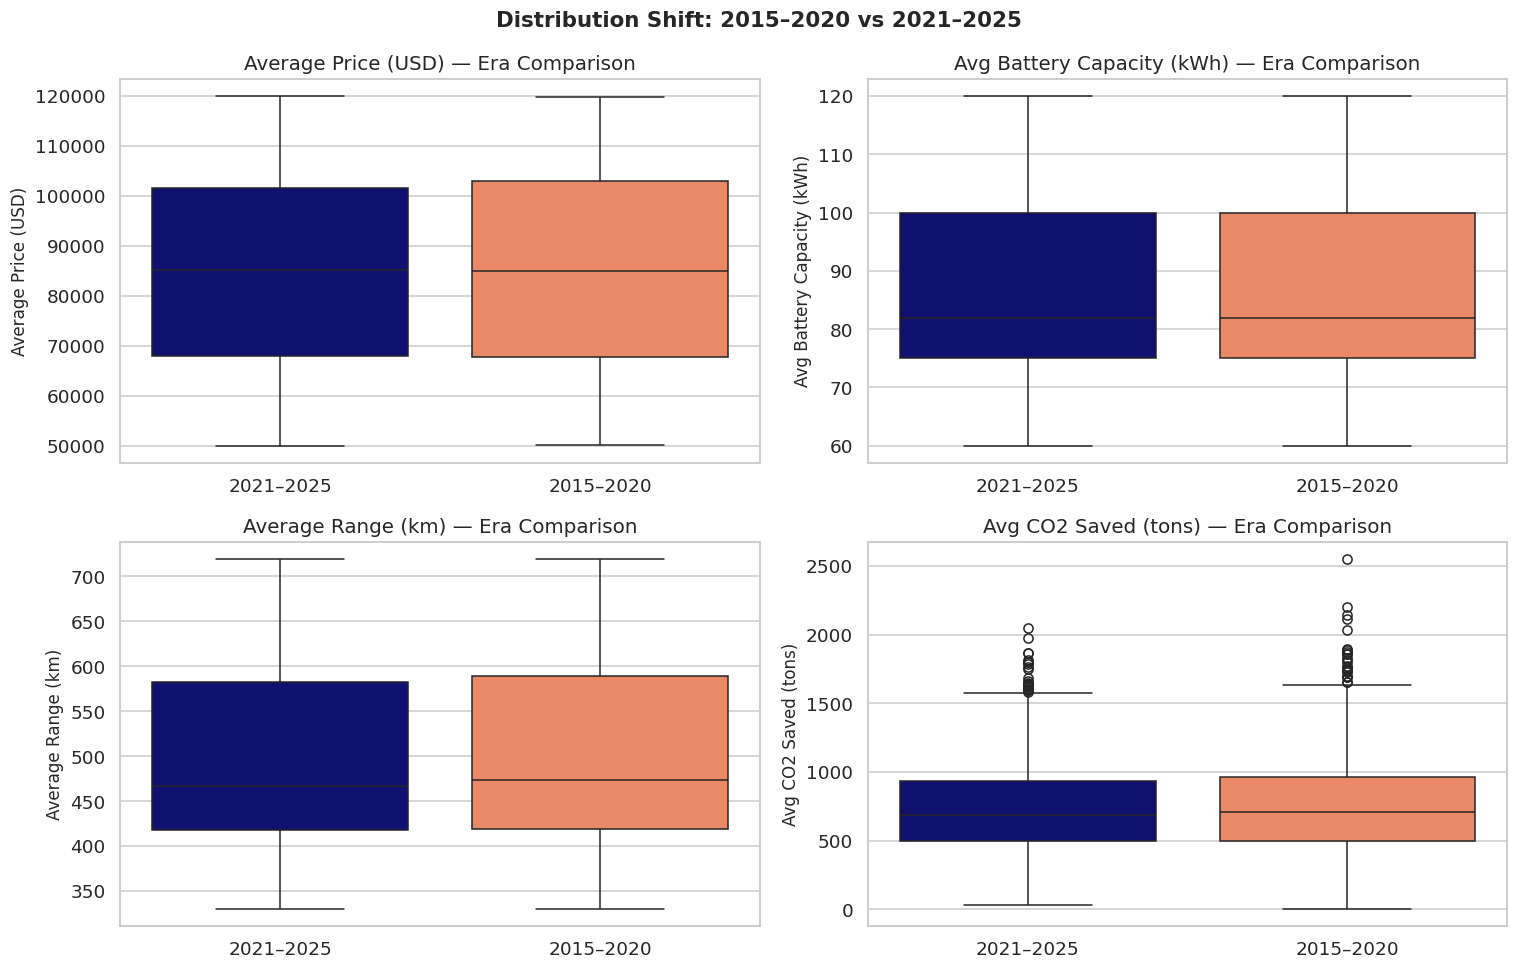

In [124]:
# Boxplot comparison: era distributions 
df['Era'] = df['Year'].apply(lambda y: '2015–2020' if y <= 2020 else '2021–2025')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, trend_metrics.items()):
    sns.boxplot(data=df, x='Era', y=col, palette=['navy', 'coral'], ax=ax)
    ax.set_title(f'{label} — Era Comparison')
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.suptitle('Distribution Shift: 2015–2020 vs 2021–2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 11 - Enhancement: K-Means Clustering
> *Discover natural vehicle segments from price, range, and battery data without using any labels.*

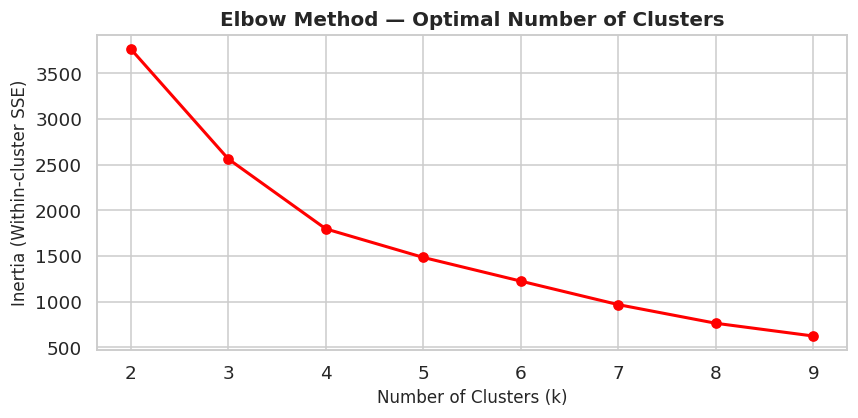

In [125]:
# Features for clustering - vehicle specs and price
cluster_feats = ['Avg_Price_USD', 'Range_km', 'Battery_Capacity_kWh']
X_clust = df[cluster_feats].dropna()

# Scale before KMeans (distance-based algorithm)
sc_clust = StandardScaler()
X_clust_sc = sc_clust.fit_transform(X_clust)

# Elbow method - find optimal k 
inertias = []
K_range  = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_clust_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, marker='o', linewidth=2, color='red')
ax.set_title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-cluster SSE)')
plt.tight_layout()
plt.show()

In [126]:
# Fit K-Means with k=3
# 3 clusters maps naturally to budget / mid-range / premium
K_BEST = 3
km = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=10)
cluster_labels = km.fit_predict(X_clust_sc)

X_clust = X_clust.copy()
X_clust['Cluster'] = cluster_labels

# Name clusters by their average price (budget < mid < premium)
price_order = X_clust.groupby('Cluster')['Avg_Price_USD'].mean().sort_values()
label_map   = {price_order.index[0]: 'Budget',
               price_order.index[1]: 'Mid-Range',
               price_order.index[2]: 'Premium'}
X_clust['Segment'] = X_clust['Cluster'].map(label_map)

print('Cluster sizes:')
print(X_clust['Segment'].value_counts())
print('\nCluster means:')
print(X_clust.groupby('Segment')[cluster_feats].mean().round(0))

Cluster sizes:
Segment
Mid-Range    1028
Premium       817
Budget        795
Name: count, dtype: int64

Cluster means:
           Avg_Price_USD  Range_km  Battery_Capacity_kWh
Segment                                                 
Budget           67374.0     416.0                  72.0
Mid-Range        84753.0     634.0                 110.0
Premium         102163.0     414.0                  72.0


PCA explained variance: 99.8%


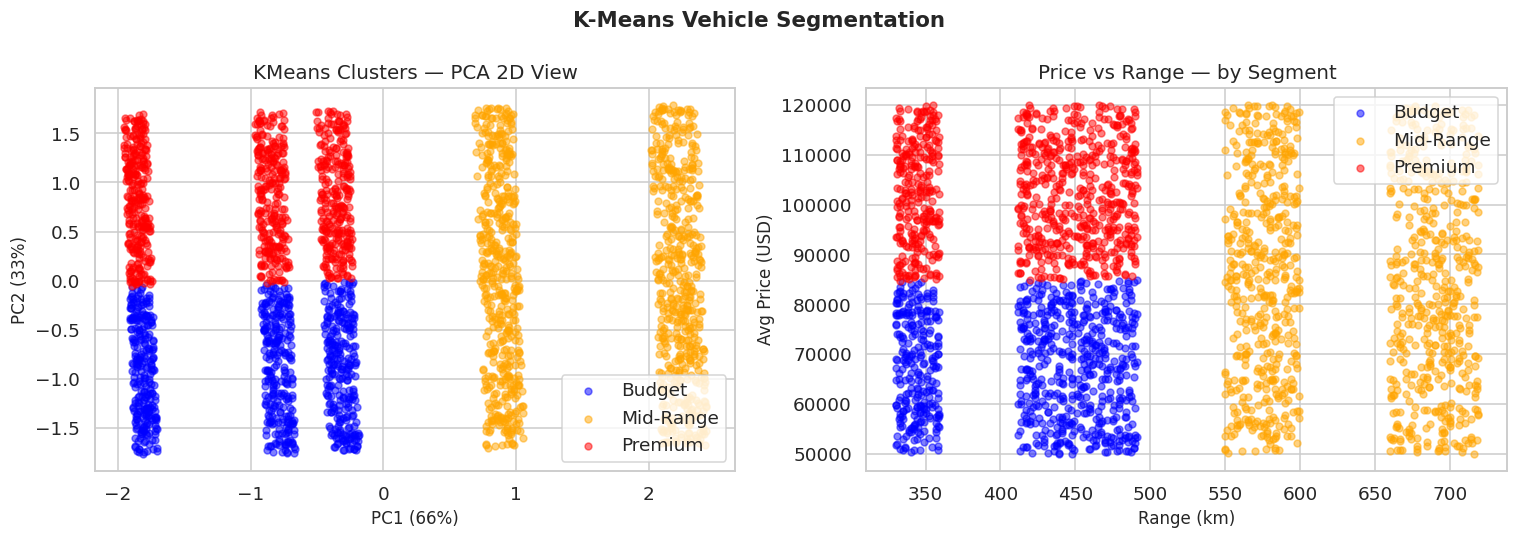

In [127]:
# PCA to 2D for visualisation
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_clust_sc)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
colors = {'Budget': 'blue', 'Mid-Range': 'orange', 'Premium': 'red'}
for seg, grp in X_clust.groupby('Segment'):
    idx = grp.index
    axes[0].scatter(X_pca[X_clust.index.get_indexer(idx), 0],
                    X_pca[X_clust.index.get_indexer(idx), 1],
                    label=seg, alpha=0.5, s=20, color=colors[seg])
axes[0].set_title('KMeans Clusters — PCA 2D View')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
axes[0].legend()

# Price vs Range scatter coloured by segment
for seg, grp in X_clust.groupby('Segment'):
    axes[1].scatter(grp['Range_km'], grp['Avg_Price_USD'],
                    label=seg, alpha=0.5, s=20, color=colors[seg])
axes[1].set_title('Price vs Range — by Segment')
axes[1].set_xlabel('Range (km)')
axes[1].set_ylabel('Avg Price (USD)')
axes[1].legend()

plt.suptitle('K-Means Vehicle Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

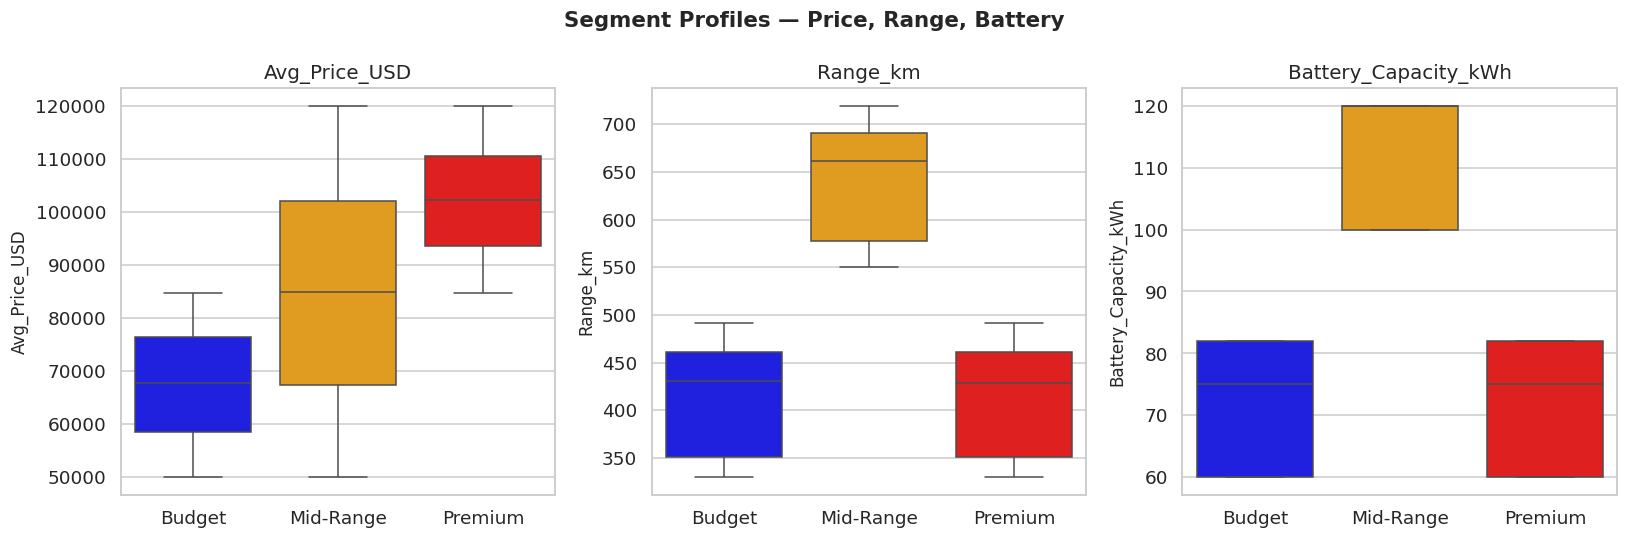

In [128]:
# Boxplots of segments across all 3 features 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
order = ['Budget', 'Mid-Range', 'Premium']
palette = {'Budget': 'blue', 'Mid-Range': 'orange', 'Premium': 'red'}

for ax, col in zip(axes, cluster_feats):
    sns.boxplot(data=X_clust, x='Segment', y=col,
                order=order, palette=palette, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Segment Profiles — Price, Range, Battery',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 12 - Conclusions

### Requirements

| Requirement | Implementation |
|---|---|
| Preprocessing | Missing value check, duplicate removal, datetime construction, label encoding |
| EDA | 11 visualisations covering trends, seasonality, correlations, region/model analysis |
| Feature Engineering | Cyclical encoding, lag features (1/3/6), rolling averages, ratio features |
| Regression | Linear Regression with RMSE, MAE, R² on held-out test set |
| Hyperparameter Tuning | Ridge / Lasso / ElasticNet — GridSearchCV over alpha (and l1_ratio for ElasticNet) |
| Time Series Forecasting | Linear Regression + lag features (Lag_1/2/3, RollingMean_3/6), 12-month recursive forecast |

### Enhancements 

> *Linear Regression was implemented as the core syllabus model. The following were added as self-initiated enhancements.*

| Enhancement | Value Added |
|---|---|
| Random Forest & XGBoost | Demonstrates that non-linear models significantly outperform linear baselines on this data |
| Regularisation Paths | Visualises how Ridge/Lasso shrink/zero coefficients as alpha increases |
| CV Score Table | Mean +- Std RMSE across folds for all three regularised models |
| SHAP Explainability | Answers *why* predictions are made — global importance, direction, and individual dependence |
| Error Analysis | Identifies which regions and models are hardest to predict |
| Trend Analysis | Quantifies how Tesla's product has evolved across two distinct eras |
| K-Means Clustering | Discovers natural vehicle segments without supervision |

### Key Findings
- **Lag features dominate** predictions - recent delivery history is the strongest predictor of future deliveries
- **Lasso zeroes out** low-signal features, confirming only a handful of features matter for linear prediction
- **ElasticNet** bridges Ridge and Lasso - best when features are correlated (as they are here)
- **Q4 seasonality** is consistently strong - deliveries spike at year-end across all regions
- **2021–2025 era** shows higher battery capacity and range at lower average prices
- **Recursive LR forecast** captures the upward trend while remaining interpretable